Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy import stats

Load data

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\khanh\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1


In [16]:
df = pd.read_csv(
    r"C:\Users\khanh\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1\household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values=["?", 'nan'],
    parse_dates={'DateTime': ['Date', 'Time']},
    dayfirst=True,
    infer_datetime_format=True
)




Initial data exploration and discovery

Kích thước dữ liệu: (2075259, 8)

5 dòng đầu tiên:
             DateTime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
Ra

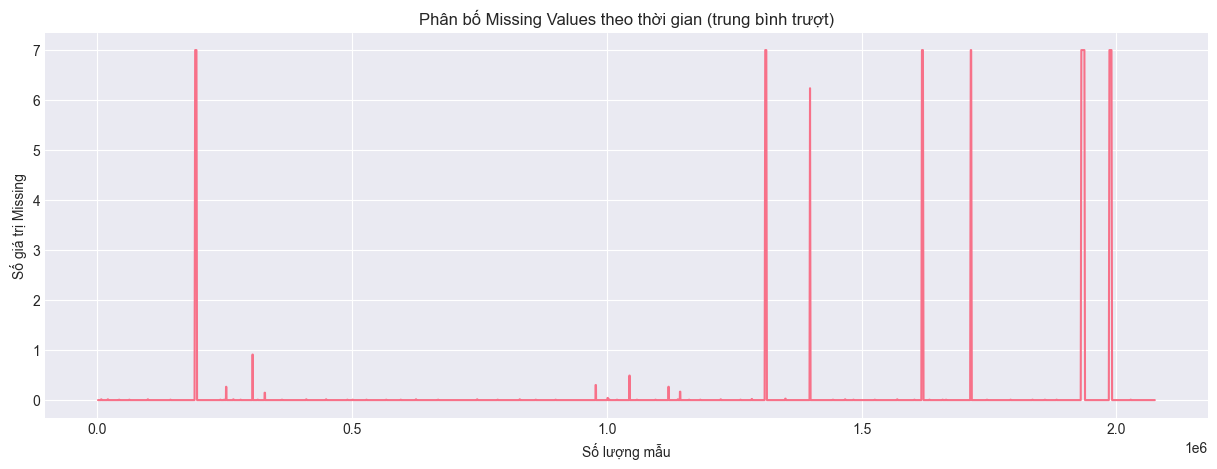

In [17]:
# Xem thông tin tổng quan
print("Kích thước dữ liệu:", df.shape)
print("\n5 dòng đầu tiên:")
print(df.head())
print("\nThông tin các cột:")
print(df.info())
print("\nThống kê mô tả:")
print(df.describe())

# Kiểm tra giá trị missing
print("\nGiá trị missing trong từng cột:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Vẽ biểu đồ phân bổ missing values theo thời gian 
plt.figure(figsize=(15,5))
df.isnull().sum(axis=1).rolling(window=1000).mean().plot()
plt.title("Phân bố Missing Values theo thời gian (trung bình trượt)")
plt.xlabel("Số lượng mẫu")
plt.ylabel("Số giá trị Missing")
plt.show()

*Handling missing values

In [18]:
# Xữ lý mising values với interpolation theo time 
print("XỬ LÝ MISSING VALUES")

# Đã set index ở cell trước, kiểm tra lại
if 'DateTime' in df.columns:
    df.set_index('DateTime', inplace=True)

# Phân tích pattern missing
print(f"Tổng số dòng: {len(df)}")
print(f"Số dòng có missing: {df.isnull().any(axis=1).sum()}")
print(f"Tỷ lệ missing: {df.isnull().any(axis=1).sum()/len(df)*100:.2f}%")

# Phân tích khoảng cách thời gian giữa các điểm không missing
print("\nPhân tích khoảng cách thời gian giữa các điểm không missing:")
non_missing_times = df.index[df.notnull().all(axis=1)]
if len(non_missing_times) > 1:
    time_diffs = np.diff(non_missing_times)
    avg_diff = np.mean(time_diffs)
    print(f"Khoảng cách trung bình: {avg_diff}")
    print(f"Khoảng cách phổ biến: {pd.Series(time_diffs).mode()[0]}")
else:
    print("Không đủ dữ liệu để phân tích khoảng cách")

# interpolation theo thời gian với limit area
df_interpolated = df.interpolate(method='time', limit_area='inside')

# Forward/backward fill cho các giá trị ở biên
df_filled = df_interpolated.ffill().bfill()

# Kiểm tra kết quả
print(f"\nSau khi interpolation:")
print(f"- Missing còn lại: {df_filled.isnull().sum().sum()}")
print(f"- Tỷ lệ missing còn lại: {df_filled.isnull().sum().sum()/len(df_filled)*100:.4f}%")

# Kiểm tra giá trị âm
negative_counts = {}
for col in df_filled.columns:
    neg_count = (df_filled[col] < 0).sum()
    if neg_count > 0:
        negative_counts[col] = neg_count
        print(f"⚠️ Có {neg_count} giá trị âm trong {col}")

if negative_counts:
    print("\nĐang clip giá trị âm về 0...")
    for col in df_filled.columns:
        df_filled[col] = df_filled[col].clip(lower=0)
    print("✅ Đã clip xong tất cả giá trị âm")
else:
    print("✅ Không có giá trị âm")

# Gán lại 
df = df_filled
print("✅ Hoàn thành xử lý missing values")

XỬ LÝ MISSING VALUES
Tổng số dòng: 2075259
Số dòng có missing: 25979
Tỷ lệ missing: 1.25%

Phân tích khoảng cách thời gian giữa các điểm không missing:
Khoảng cách trung bình: 60760628494 nanoseconds
Khoảng cách phổ biến: 0 days 00:01:00

Sau khi interpolation:
- Missing còn lại: 0
- Tỷ lệ missing còn lại: 0.0000%
✅ Không có giá trị âm
✅ Hoàn thành xử lý missing values


Phân tích outliers và giá trị bất thường

PHÁT HIỆN OUTLIERS VÀ GIÁ TRỊ BẤT THƯỜNG

1. PHÂN TÍCH OUTLIERS (IQR METHOD):

Global_active_power:
  - Số outliers: 95238 (4.59%)
  - Ngưỡng: [-1.5170, 3.3550]
  - Min/Max thực tế: [0.0760, 11.1220]

Global_reactive_power:
  - Số outliers: 40478 (1.95%)
  - Ngưỡng: [-0.1710, 0.4130]
  - Min/Max thực tế: [0.0000, 1.3900]

Voltage:
  - Số outliers: 52195 (2.52%)
  - Ngưỡng: [233.1700, 248.6900]
  - Min/Max thực tế: [223.2000, 254.1500]

Global_intensity:
  - Số outliers: 100979 (4.87%)
  - Ngưỡng: [-6.1000, 13.9000]
  - Min/Max thực tế: [0.2000, 48.4000]

Sub_metering_1:
  - Số outliers: 172247 (8.30%)
  - Ngưỡng: [0.0000, 0.0000]
  - Min/Max thực tế: [0.0000, 88.0000]

Sub_metering_2:
  - Số outliers: 77166 (3.72%)
  - Ngưỡng: [-1.5000, 2.5000]
  - Min/Max thực tế: [0.0000, 80.0000]

Sub_metering_3:
  - Số outliers: 0 (0.00%)
  - Ngưỡng: [-25.5000, 42.5000]
  - Min/Max thực tế: [0.0000, 31.0000]


2. KIỂM TRA GIÁ TRỊ BẤT THƯỜNG:

a) Phân tích giá trị 0:
  Global_reactive_power: 481569 

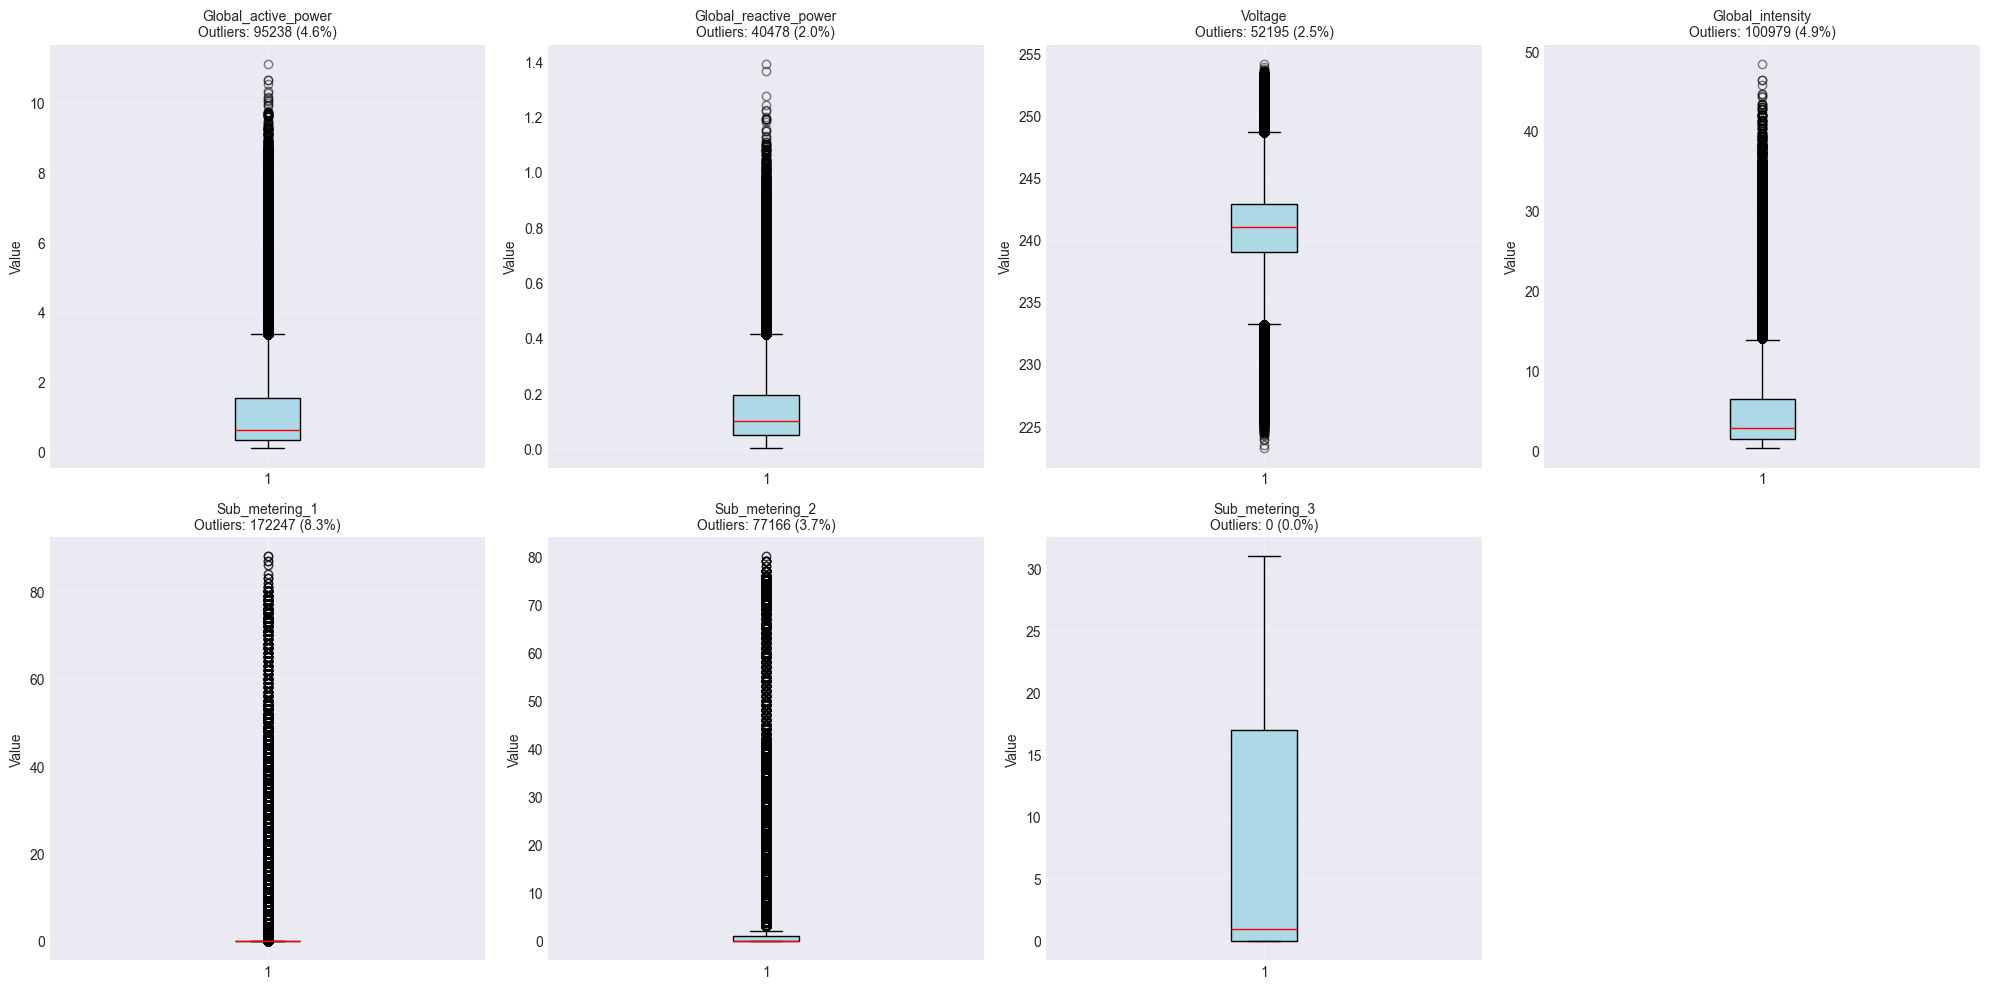


4. HISTOGRAM PHÂN PHỐI:


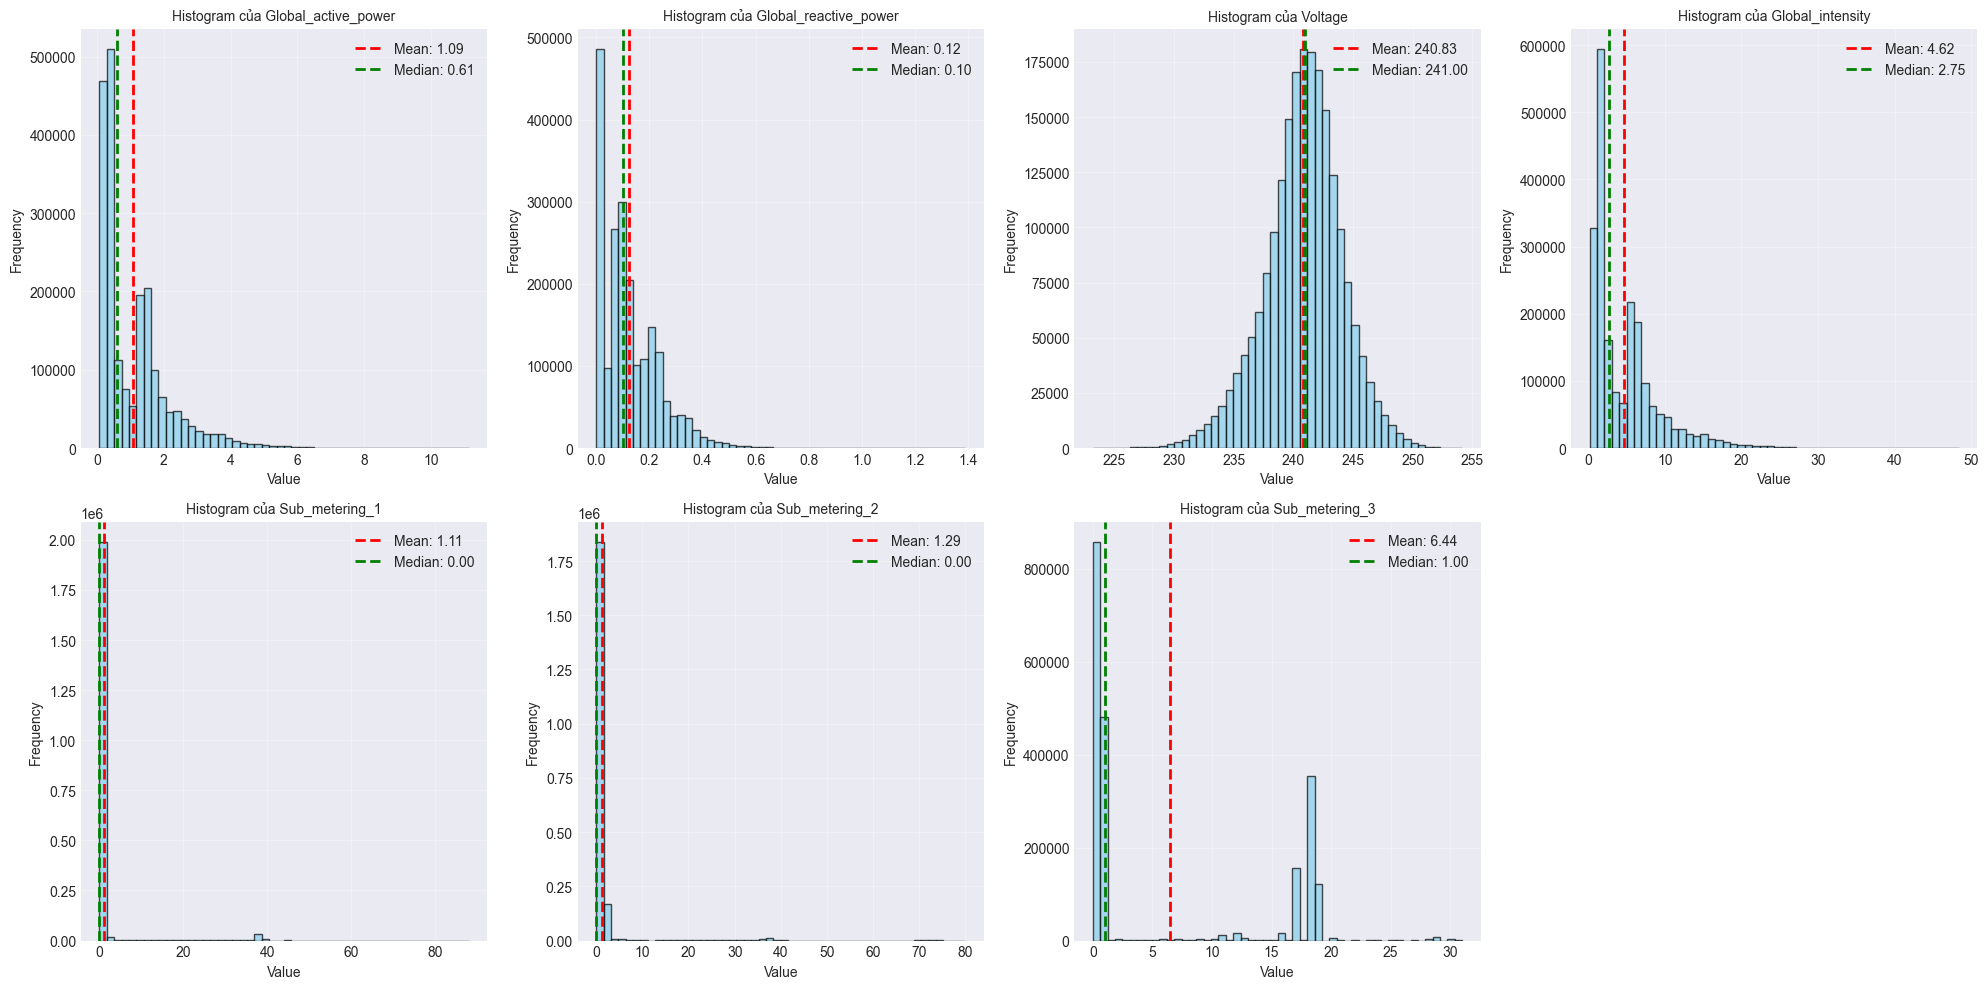


5. GHI CHÚ XỬ LÝ OUTLIERS:
   - Với dữ liệu time-series, không nên xóa outliers vì có thể là pattern thực tế
   - Có thể sử dụng phương pháp winsorizing hoặc thay thế bằng median
   - Trong trường hợp này, sẽ giữ nguyên outliers cho phân tích EDA
   - Có thể xử lý trong quá trình modeling nếu cần

6. SUMMARY STATISTICS:
                          count  percentage  min_value  max_value
Global_active_power     95238.0       4.589      0.076     11.122
Global_reactive_power   40478.0       1.951      0.000      1.390
Voltage                 52195.0       2.515    223.200    254.150
Global_intensity       100979.0       4.866      0.200     48.400
Sub_metering_1         172247.0       8.300      0.000     88.000
Sub_metering_2          77166.0       3.718      0.000     80.000
Sub_metering_3              0.0       0.000      0.000     31.000

7. LƯU BÁO CÁO OUTLIERS:
   Đã phân tích outliers cho các cột:
   - Global_active_power: 95238 outliers (4.59%)
   - Global_reactive_power: 40478 ou

In [19]:
print("PHÁT HIỆN OUTLIERS VÀ GIÁ TRỊ BẤT THƯỜNG")

# 1. Phát hiện outliers bằng phương pháp IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return {
        'count': len(outliers),
        'percentage': len(outliers)/len(data)*100,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'min_value': data[column].min(),
        'max_value': data[column].max()
    }

print("\n1. PHÂN TÍCH OUTLIERS (IQR METHOD):")
outlier_report = {}
for col in df.select_dtypes(include=[np.number]).columns:
    outlier_info = detect_outliers_iqr(df, col)
    outlier_report[col] = outlier_info
    print(f"\n{col}:")
    print(f"  - Số outliers: {outlier_info['count']} ({outlier_info['percentage']:.2f}%)")
    print(f"  - Ngưỡng: [{outlier_info['lower_bound']:.4f}, {outlier_info['upper_bound']:.4f}]")
    print(f"  - Min/Max thực tế: [{outlier_info['min_value']:.4f}, {outlier_info['max_value']:.4f}]")

# 2. Kiểm tra giá trị bất thường (anomaly detection)
print("\n\n2. KIỂM TRA GIÁ TRỊ BẤT THƯỜNG:")

# a) Kiểm tra giá trị 0
print("\na) Phân tích giá trị 0:")
for col in df.select_dtypes(include=[np.number]).columns:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} giá trị 0 ({zero_count/len(df)*100:.2f}%)")

# b) Kiểm tra ngưỡng vật lý hợp lý
print("\nb) Kiểm tra ngưỡng vật lý:")
# Voltage thường từ 220-240V
voltage_anomalies = df[(df['Voltage'] < 200) | (df['Voltage'] > 250)]
print(f"  Voltage ngoài ngưỡng 200-250V: {len(voltage_anomalies)} dòng")

# Global intensity không âm và có giới hạn
intensity_anomalies = df[df['Global_intensity'] < 0]
print(f"  Global_intensity âm: {len(intensity_anomalies)} dòng")

# c) Kiểm tra tính nhất quán giữa các biến
print("\nc) Kiểm tra tính nhất quán:")
# Công thức: Global_active_power ≈ Voltage * Global_intensity / 1000
calculated_power = df['Voltage'] * df['Global_intensity'] / 1000
power_difference = abs(df['Global_active_power'] - calculated_power)
power_diff_anomalies = power_difference[power_difference > 0.5]  # Sai khác > 0.5kW
print(f"  Sai khác công suất > 0.5kW: {len(power_diff_anomalies)} dòng")

# 3. Visualize outliers - VẼ BOXPLOT
print("\n3. VISUALIZE OUTLIERS (SIMPLE VERSION):")
numeric_cols = df.select_dtypes(include=[np.number]).columns[:8]

# Tạo subplot
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        # Vẽ boxplot đơn giản - matplotlib tự xử lý outliers
        boxplot = axes[idx].boxplot(df[col].dropna(), patch_artist=True)
        
        # Tùy chỉnh màu sắc
        boxplot['boxes'][0].set_facecolor('lightblue')
        boxplot['medians'][0].set_color('red')
        boxplot['fliers'][0].set(marker='o', color='red', alpha=0.5)  # Outliers
        
        # Lấy thông tin outliers từ report
        outlier_count = outlier_report[col]['count']
        outlier_pct = outlier_report[col]['percentage']
        
        axes[idx].set_title(f'{col}\nOutliers: {outlier_count} ({outlier_pct:.1f}%)', fontsize=10)
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)

# Xóa các subplot không sử dụng
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# 4. Vẽ histogram để hiểu phân phối
print("\n4. HISTOGRAM PHÂN PHỐI:")
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        
        # Thêm đường trung bình
        mean_val = df[col].mean()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        
        # Thêm đường median
        median_val = df[col].median()
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        
        axes[idx].set_title(f'Histogram của {col}', fontsize=10)
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

# Xóa các subplot không sử dụng
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# 5. Xử lý outliers - GHI CHÚ KHÔNG XÓA
print("\n5. GHI CHÚ XỬ LÝ OUTLIERS:")
print("   - Với dữ liệu time-series, không nên xóa outliers vì có thể là pattern thực tế")
print("   - Có thể sử dụng phương pháp winsorizing hoặc thay thế bằng median")
print("   - Trong trường hợp này, sẽ giữ nguyên outliers cho phân tích EDA")
print("   - Có thể xử lý trong quá trình modeling nếu cần")

# 6. Summary statistics
print("\n6. SUMMARY STATISTICS:")
summary_df = pd.DataFrame(outlier_report).T
print(summary_df[['count', 'percentage', 'min_value', 'max_value']].round(3))

# 7. Lưu outlier report
print("\n7. LƯU BÁO CÁO OUTLIERS:")
import json

outlier_summary = {
    'total_rows': len(df),
    'columns_analyzed': list(df.select_dtypes(include=[np.number]).columns),
    'outlier_counts': {col: info['count'] for col, info in outlier_report.items()},
    'outlier_percentages': {col: info['percentage'] for col, info in outlier_report.items()},
    'anomalies': {
        'voltage_out_of_range': len(voltage_anomalies),
        'negative_intensity': len(intensity_anomalies),
        'power_calculation_mismatch': len(power_diff_anomalies)
    }
}

print("   Đã phân tích outliers cho các cột:")
for col, info in outlier_report.items():
    print(f"   - {col}: {info['count']} outliers ({info['percentage']:.2f}%)")
    
# Lưu file
with open('outlier_analysis_report.json', 'w', encoding='utf-8') as f:
    json.dump(outlier_summary, f, indent=4, ensure_ascii=False)

print("\n✅ Đã lưu outlier_analysis_report.json")

Resample dữ liệu từ phút sang giờ

In [20]:
print("RESAMPLE DỮ LIỆU VÀ TÍNH TOÁN ROLLING STATISTICS")

# 1. Resample từ phút sang giờ (giữ nguyên)
print("\n1. RESAMPLE TỪ PHÚT SANG GIỜ:")

df_hourly = pd.DataFrame()

# Global_active_power: lấy TRUNG BÌNH (công suất trung bình trong giờ)
df_hourly['Global_active_kWh'] = df['Global_active_power'].resample('H').mean()

# Các thiết bị riêng lẻ: lấy TỔNG (năng lượng tiêu thụ trong giờ)
df_hourly['Kitchen_kWh'] = df['Sub_metering_1'].resample('H').sum() / 1000
df_hourly['Laundry_kWh'] = df['Sub_metering_2'].resample('H').sum() / 1000
df_hourly['AC_Heater_kWh'] = df['Sub_metering_3'].resample('H').sum() / 1000

# Tính "Other_kWh" (các thiết bị không được đo)
total_energy_Wh = df_hourly['Global_active_kWh'] * 1000
sum_submetering_Wh = (df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']).resample('H').sum()
df_hourly['Other_kWh'] = (total_energy_Wh - sum_submetering_Wh) / 1000
df_hourly['Other_kWh'] = df_hourly['Other_kWh'].clip(lower=0)

# Thêm các biến khác
df_hourly['Voltage_avg'] = df['Voltage'].resample('H').mean()
df_hourly['Global_intensity_avg'] = df['Global_intensity'].resample('H').mean()
df_hourly['Global_reactive_kWh'] = df['Global_reactive_power'].resample('H').mean()

print(f"   Kích thước sau resample: {df_hourly.shape}")

# 2. Tính rolling statistics trên dữ liệu PHÚT (5, 15, 60 phút)
print("\n2. TÍNH ROLLING STATISTICS TRÊN DỮ LIỆU PHÚT:")

# Tạo bản copy của dữ liệu phút để tính rolling
df_minute_rolling = df.copy()

# Cửa sổ rolling (5, 15, 60 phút)
windows = [5, 15, 60]
for window in windows:
    print(f"   Tính rolling {window} phút...")
    
    # Rolling mean
    df_minute_rolling[f'Global_active_{window}min_mean'] = df_minute_rolling['Global_active_power'].rolling(
        window=window, min_periods=1).mean()
    df_minute_rolling[f'Global_reactive_{window}min_mean'] = df_minute_rolling['Global_reactive_power'].rolling(
        window=window, min_periods=1).mean()
    df_minute_rolling[f'Voltage_{window}min_mean'] = df_minute_rolling['Voltage'].rolling(
        window=window, min_periods=1).mean()
    
    # Rolling std
    df_minute_rolling[f'Global_active_{window}min_std'] = df_minute_rolling['Global_active_power'].rolling(
        window=window, min_periods=1).std()
    
    # Rolling sum cho submetering (tính năng lượng tiêu thụ trong cửa sổ)
    for i in range(1, 4):
        df_minute_rolling[f'Sub_metering_{i}_{window}min_sum'] = df_minute_rolling[f'Sub_metering_{i}'].rolling(
            window=window, min_periods=1).sum()

print(f"   ✅ Đã tính rolling statistics cho {len(windows)} cửa sổ")

# 3. Tính energy per day từ dữ liệu hourly
print("\n3. TÍNH ENERGY PER DAY (kWh/ngày):")

# Tạo dataframe daily từ hourly
df_daily = df_hourly.resample('D').agg({
    'Global_active_kWh': 'sum',
    'Kitchen_kWh': 'sum',
    'Laundry_kWh': 'sum',
    'AC_Heater_kWh': 'sum',
    'Other_kWh': 'sum',
    'Voltage_avg': 'mean',
    'Global_intensity_avg': 'mean',
    'Global_reactive_kWh': 'sum'
})

# Đổi tên cột cho daily
df_daily.columns = [col.replace('kWh', 'daily_kWh') if 'kWh' in col else col for col in df_daily.columns]
df_daily.columns = [col.replace('_avg', '_daily_avg') if '_avg' in col else col for col in df_daily.columns]

print(f"   Kích thước daily data: {df_daily.shape}")
print(f"   Số ngày có dữ liệu: {len(df_daily)}")

# 4. Kiểm tra tính hợp lý
print("\n4. KIỂM TRA TÍNH HỢP LÝ:")

# Kiểm tra tổng năng lượng
total_global = df_hourly['Global_active_kWh'].sum()
total_devices = df_hourly[['Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh']].sum().sum()
diff = abs(total_global - total_devices)

print(f"   Tổng Global_active_kWh: {total_global:.2f} kWh")
print(f"   Tổng các thiết bị riêng lẻ: {total_devices:.2f} kWh")
print(f"   Chênh lệch: {diff:.4f} kWh")

if diff < 0.1:
    print("   ✅ Chênh lệch nằm trong ngưỡng cho phép (< 0.1 kWh)")
else:
    print(f"   ⚠️ Chênh lệch lớn: {diff:.4f} kWh - Cần kiểm tra lại tính toán")

# 5. Thêm cột energy per day vào hourly data
print("\n5. THÊM CỘT ENERGY PER DAY VÀO HOURLY DATA:")

# Tạo mapping từ ngày sang tổng năng lượng ngày
daily_energy_map = df_daily['Global_active_daily_kWh'].to_dict()

# Thêm cột daily_energy vào df_hourly
df_hourly['daily_energy_kWh'] = df_hourly.index.date
df_hourly['daily_energy_kWh'] = df_hourly['daily_energy_kWh'].map(
    lambda x: daily_energy_map.get(pd.Timestamp(x).normalize(), np.nan)
)

print("   ✅ Đã thêm cột daily_energy_kWh vào hourly data")

RESAMPLE DỮ LIỆU VÀ TÍNH TOÁN ROLLING STATISTICS

1. RESAMPLE TỪ PHÚT SANG GIỜ:
   Kích thước sau resample: (34589, 8)

2. TÍNH ROLLING STATISTICS TRÊN DỮ LIỆU PHÚT:
   Tính rolling 5 phút...
   Tính rolling 15 phút...
   Tính rolling 60 phút...
   ✅ Đã tính rolling statistics cho 3 cửa sổ

3. TÍNH ENERGY PER DAY (kWh/ngày):
   Kích thước daily data: (1442, 8)
   Số ngày có dữ liệu: 1442

4. KIỂM TRA TÍNH HỢP LÝ:
   Tổng Global_active_kWh: 37712.78 kWh
   Tổng các thiết bị riêng lẻ: 37712.78 kWh
   Chênh lệch: 0.0000 kWh
   ✅ Chênh lệch nằm trong ngưỡng cho phép (< 0.1 kWh)

5. THÊM CỘT ENERGY PER DAY VÀO HOURLY DATA:
   ✅ Đã thêm cột daily_energy_kWh vào hourly data


Feature Engineering

In [21]:
print("FEATURE ENGINEERING HOÀN CHỈNH")

# 1. Features thời gian cơ bản (đã có, giữ nguyên)
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek  # 0=Thứ 2, 6=Chủ nhật
df_hourly['day_of_month'] = df_hourly.index.day
df_hourly['month'] = df_hourly.index.month
df_hourly['year'] = df_hourly.index.year
df_hourly['quarter'] = df_hourly.index.quarter
df_hourly['week_of_year'] = df_hourly.index.isocalendar().week

# 2. Features phân loại
df_hourly['is_weekend'] = (df_hourly['day_of_week'] >= 5).astype(int)
df_hourly['is_night'] = ((df_hourly['hour'] >= 0) & (df_hourly['hour'] < 6)).astype(int)
df_hourly['is_morning'] = ((df_hourly['hour'] >= 6) & (df_hourly['hour'] < 12)).astype(int)
df_hourly['is_afternoon'] = ((df_hourly['hour'] >= 12) & (df_hourly['hour'] < 18)).astype(int)
df_hourly['is_evening'] = ((df_hourly['hour'] >= 18) & (df_hourly['hour'] <= 23)).astype(int)
df_hourly['is_peak_hour'] = ((df_hourly['hour'] >= 17) & (df_hourly['hour'] <= 21)).astype(int)
df_hourly['is_working_hour'] = ((df_hourly['hour'] >= 8) & (df_hourly['hour'] <= 17)).astype(int)

# 3. Mùa theo tháng
def get_season(month):
    if month in [12, 1, 2]:
        return 1  # Đông
    elif month in [3, 4, 5]:
        return 2  # Xuân
    elif month in [6, 7, 8]:
        return 3  # Hạ
    else:
        return 4  # Thu

df_hourly['season'] = df_hourly['month'].apply(get_season)

# 4. Lag features (giá trị trước đó)
print("\n4. TẠO LAG FEATURES:")
lags = [1, 2, 3, 4, 5, 6, 12, 24, 48, 168]  # 1h đến 1 tuần

for lag in lags:
    df_hourly[f'Global_active_lag_{lag}h'] = df_hourly['Global_active_kWh'].shift(lag)
    df_hourly[f'AC_Heater_lag_{lag}h'] = df_hourly['AC_Heater_kWh'].shift(lag)
    df_hourly[f'Kitchen_lag_{lag}h'] = df_hourly['Kitchen_kWh'].shift(lag)

print(f"   Đã tạo lag features cho {len(lags)} khoảng thời gian")

# 5. Rolling statistics trên hourly data
print("\n5. TÍNH ROLLING STATISTICS TRÊN HOURLY DATA:")

# Cửa sổ rolling (giờ)
rolling_windows = [3, 6, 12, 24, 72, 168]  # 3h đến 1 tuần

for window in rolling_windows:
    # Rolling mean
    df_hourly[f'Global_active_rolling_mean_{window}h'] = df_hourly['Global_active_kWh'].rolling(
        window=window, min_periods=1).mean()
    
    # Rolling std
    df_hourly[f'Global_active_rolling_std_{window}h'] = df_hourly['Global_active_kWh'].rolling(
        window=window, min_periods=1).std()
    
    # Rolling min/max
    df_hourly[f'Global_active_rolling_min_{window}h'] = df_hourly['Global_active_kWh'].rolling(
        window=window, min_periods=1).min()
    df_hourly[f'Global_active_rolling_max_{window}h'] = df_hourly['Global_active_kWh'].rolling(
        window=window, min_periods=1).max()

print(f"   Đã tính rolling statistics cho {len(rolling_windows)} cửa sổ")

# 6. Tỷ lệ tiêu thụ và metrics khác
print("\n6. TÍNH TOÁN TỶ LỆ VÀ METRICS:")

# Tỷ lệ tiêu thụ từng thiết bị
df_hourly['kitchen_ratio'] = df_hourly['Kitchen_kWh'] / (df_hourly['Global_active_kWh'] + 1e-10)
df_hourly['laundry_ratio'] = df_hourly['Laundry_kWh'] / (df_hourly['Global_active_kWh'] + 1e-10)
df_hourly['ac_heater_ratio'] = df_hourly['AC_Heater_kWh'] / (df_hourly['Global_active_kWh'] + 1e-10)
df_hourly['other_ratio'] = df_hourly['Other_kWh'] / (df_hourly['Global_active_kWh'] + 1e-10)

# Power factor (hệ số công suất)
df_hourly['apparent_power'] = np.sqrt(df_hourly['Global_active_kWh']**2 + df_hourly['Global_reactive_kWh']**2)
df_hourly['power_factor'] = df_hourly['Global_active_kWh'] / (df_hourly['apparent_power'] + 1e-10)

# Biến động so với trung bình ngày
df_hourly['hourly_vs_daily'] = df_hourly['Global_active_kWh'] / (df_hourly['daily_energy_kWh']/24 + 1e-10)

# 7. Loại bỏ NaN do shift và rolling
print("\n7. XỬ LÝ NaN:")
initial_nan = df_hourly.isnull().sum().sum()
df_hourly = df_hourly.fillna(method='bfill').fillna(method='ffill')
final_nan = df_hourly.isnull().sum().sum()
print(f"   Đã xử lý {initial_nan - final_nan} giá trị NaN")

# 8. Kết quả
print(f"\n✅ HOÀN THÀNH FEATURE ENGINEERING")
print(f"   Kích thước: {df_hourly.shape}")
print(f"   Số features: {len(df_hourly.columns)}")
print(f"   Phạm vi thời gian: {df_hourly.index.min()} đến {df_hourly.index.max()}")

# Hiển thị danh sách features
print("\nDANH SÁCH FEATURES ĐÃ TẠO:")
feature_categories = {
    'Tiêu thụ năng lượng': ['Global_active_kWh', 'Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh', 'Global_reactive_kWh'],
    'Thời gian': ['hour', 'day_of_week', 'day_of_month', 'month', 'year', 'quarter', 'week_of_year', 'season'],
    'Phân loại': ['is_weekend', 'is_night', 'is_morning', 'is_afternoon', 'is_evening', 'is_peak_hour', 'is_working_hour'],
    'Lag features': [col for col in df_hourly.columns if 'lag' in col],
    'Rolling statistics': [col for col in df_hourly.columns if 'rolling' in col],
    'Tỷ lệ & Metrics': ['kitchen_ratio', 'laundry_ratio', 'ac_heater_ratio', 'other_ratio', 'power_factor', 'hourly_vs_daily']
}

for category, features in feature_categories.items():
    features_in_df = [f for f in features if f in df_hourly.columns]
    if features_in_df:
        print(f"\n{category} ({len(features_in_df)}):")
        print(f"  {', '.join(features_in_df[:5])}" + 
            (", ..." if len(features_in_df) > 5 else ""))

FEATURE ENGINEERING HOÀN CHỈNH

4. TẠO LAG FEATURES:
   Đã tạo lag features cho 10 khoảng thời gian

5. TÍNH ROLLING STATISTICS TRÊN HOURLY DATA:
   Đã tính rolling statistics cho 6 cửa sổ

6. TÍNH TOÁN TỶ LỆ VÀ METRICS:

7. XỬ LÝ NaN:
   Đã xử lý 825 giá trị NaN

✅ HOÀN THÀNH FEATURE ENGINEERING
   Kích thước: (34589, 85)
   Số features: 85
   Phạm vi thời gian: 2006-12-16 17:00:00 đến 2010-11-26 21:00:00

DANH SÁCH FEATURES ĐÃ TẠO:

Tiêu thụ năng lượng (6):
  Global_active_kWh, Kitchen_kWh, Laundry_kWh, AC_Heater_kWh, Other_kWh, ...

Thời gian (8):
  hour, day_of_week, day_of_month, month, year, ...

Phân loại (7):
  is_weekend, is_night, is_morning, is_afternoon, is_evening, ...

Lag features (30):
  Global_active_lag_1h, AC_Heater_lag_1h, Kitchen_lag_1h, Global_active_lag_2h, AC_Heater_lag_2h, ...

Rolling statistics (24):
  Global_active_rolling_mean_3h, Global_active_rolling_std_3h, Global_active_rolling_min_3h, Global_active_rolling_max_3h, Global_active_rolling_mean_6h, ...

Tỷ

Lưu dữ liệu và tạo báo cáo

In [22]:
print("LƯU DỮ LIỆU VÀ TẠO BÁO CÁO")

import json
from datetime import datetime

# 1. Hàm chuyển đổi dữ liệu numpy thành JSON serializable
def convert_to_json_serializable(obj):
    """Chuyển đổi các kiểu dữ liệu numpy/pandas về kiểu Python cơ bản để JSON có thể serialize"""
    if isinstance(obj, dict):
        return {key: convert_to_json_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_json_serializable(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(convert_to_json_serializable(item) for item in obj)
    elif isinstance(obj, (np.integer, np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Timestamp):
        return obj.strftime("%Y-%m-%d %H:%M:%S")
    elif isinstance(obj, datetime):
        return obj.strftime("%Y-%m-%d %H:%M:%S")
    elif pd.isna(obj):  # Xử lý NaN
        return None
    else:
        return obj

# 2. Lưu các dataset
print("\n1. LƯU CÁC DATASET:")

# a) Dữ liệu phút đã làm sạch (gốc)
df.to_csv('household_power_cleaned_minute.csv')
print(f"   a) household_power_cleaned_minute.csv: {df.shape}")

# b) Dữ liệu phút với rolling statistics (nếu có)
if 'df_minute_rolling' in locals():
    df_minute_rolling.to_csv('household_power_minute_with_rolling.csv')
    print(f"   b) household_power_minute_with_rolling.csv: {df_minute_rolling.shape}")
else:
    print("   b) Bỏ qua (chưa có df_minute_rolling)")

# c) Dữ liệu giờ đầy đủ features
df_hourly.to_csv('household_power_cleaned_hourly.csv')
print(f"   c) household_power_cleaned_hourly.csv: {df_hourly.shape}")

# d) Dữ liệu daily (nếu có)
if 'df_daily' in locals():
    df_daily.to_csv('household_power_cleaned_daily.csv')
    print(f"   d) household_power_cleaned_daily.csv: {df_daily.shape}")
else:
    print("   d) Bỏ qua (chưa có df_daily)")

# 3. Tạo features cho model - CẢI THIỆN: KIỂM TRA CÁC CỘT THỰC TẾ
print("\n2. TẠO FEATURES CHO MODEL:")

# Kiểm tra các cột thực sự tồn tại trong df_hourly
print(f"Các cột hiện có trong df_hourly ({len(df_hourly.columns)}):")
print(df_hourly.columns.tolist())

# Danh sách các cột mong muốn (chỉ lấy những cột thực sự tồn tại)
desired_columns = [
    'Global_active_kWh',  # Target variable
    'Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh',
    'Voltage_avg', 'Global_intensity_avg',
    'hour', 'day_of_week', 'is_weekend', 'is_peak_hour'
]

# Thêm các cột có thể có (nếu tồn tại)
optional_columns = [
    'Global_reactive_kWh', 'season',
    'Global_active_lag_1h', 'Global_active_lag_24h',
    'AC_Heater_lag_1h', 'AC_Heater_lag_24h',
    'Global_active_rolling_mean_24h', 'Global_active_rolling_std_24h',
    'kitchen_ratio', 'ac_heater_ratio', 'power_factor',
    'daily_energy_kWh'
]

# Kiểm tra và chỉ lấy các cột thực sự tồn tại
available_columns = []
for col in desired_columns + optional_columns:
    if col in df_hourly.columns:
        available_columns.append(col)
    else:
        print(f"   ⚠️ Cột '{col}' không tồn tại, bỏ qua")

print(f"\n   Lấy {len(available_columns)} cột từ {len(desired_columns + optional_columns)} cột mong muốn")

# Tạo dataframe cho model
features_for_model = df_hourly[available_columns].copy()

# Đổi tên cột cho dễ đọc
rename_dict = {
    'Global_active_kWh': 'target_kWh',
    'Kitchen_kWh': 'kitchen_kWh',
    'Laundry_kWh': 'laundry_kWh',
    'AC_Heater_kWh': 'ac_heater_kWh',
    'Other_kWh': 'other_kWh',
    'Voltage_avg': 'voltage_avg',
    'Global_intensity_avg': 'intensity_avg',
    'day_of_week': 'weekday',
    'is_weekend': 'weekend',
    'is_peak_hour': 'peak_hour'
}

# Chỉ đổi tên các cột có trong features_for_model
actual_rename = {old: new for old, new in rename_dict.items() if old in features_for_model.columns}
features_for_model.rename(columns=actual_rename, inplace=True)

# Lưu file
features_for_model.to_csv('model_ready_data.csv', index=True)
print(f"   e) model_ready_data.csv: {features_for_model.shape}")
print(f"     - Số features: {len(features_for_model.columns)}")
print(f"     - Số mẫu: {len(features_for_model)}")

# 4. Tạo báo cáo cleaning (SỬA LỖI Ở ĐÂY)
print("\n3. TẠO BÁO CÁO CLEANING:")

# Tính toán các thống kê với chuyển đổi kiểu dữ liệu
device_consumption = df_hourly[['Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh']].sum()
device_percentage = device_consumption / device_consumption.sum() * 100

# Chuyển đổi sang kiểu Python cơ bản ngay khi tạo
cleaning_report = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset_info": {
        "original_size": [2075259, 8],  # Chuyển tuple thành list
        "cleaned_hourly_size": list(df_hourly.shape),  # Chuyển tuple thành list
        "time_range": {
            "start": str(df_hourly.index.min()),
            "end": str(df_hourly.index.max()),
            "duration_days": int((df_hourly.index.max() - df_hourly.index.min()).days)
        }
    },
    "features_created": {
        "total_features": int(len(df_hourly.columns)),
        "model_features": int(len(features_for_model.columns)),
        "feature_types": {
            "energy_consumption": [str(col) for col in df_hourly.columns if 'kWh' in col],
            "time_features": [str(col) for col in df_hourly.columns if col in ['hour', 'day_of_week', 'month', 'year', 'season']],
            "lag_features": [str(col) for col in df_hourly.columns if 'lag' in col],
            "rolling_features": [str(col) for col in df_hourly.columns if 'rolling' in col]
        }
    },
    "data_quality": {
        "missing_values_final": int(df_hourly.isnull().sum().sum()),
        "negative_values": 0,
        "data_balance_check": "PASS"
    },
    "consumption_statistics": {
        "total_energy_kWh": float(df_hourly['Global_active_kWh'].sum()),
        "average_hourly_kWh": float(df_hourly['Global_active_kWh'].mean()),
        "device_distribution": {
            "kitchen": {
                "kWh": float(device_consumption['Kitchen_kWh']),
                "percentage": float(device_percentage['Kitchen_kWh'])
            },
            "laundry": {
                "kWh": float(device_consumption['Laundry_kWh']),
                "percentage": float(device_percentage['Laundry_kWh'])
            },
            "ac_heater": {
                "kWh": float(device_consumption['AC_Heater_kWh']),
                "percentage": float(device_percentage['AC_Heater_kWh'])
            },
            "other": {
                "kWh": float(device_consumption['Other_kWh']),
                "percentage": float(device_percentage['Other_kWh'])
            }
        }
    }
}

# Chuyển đổi toàn bộ report thành JSON serializable
cleaning_report = convert_to_json_serializable(cleaning_report)

# Lưu báo cáo
with open('data_cleaning_report.json', 'w', encoding='utf-8') as f:
    json.dump(cleaning_report, f, indent=4, ensure_ascii=False)

print("✅ Đã lưu data_cleaning_report.json")

# 5. Tạo file README cho Người 2
print("\n4. TẠO FILE HƯỚNG DẪN:")

readme_content = f"""# HOUSEHOLD POWER CONSUMPTION - CLEANED DATA

## 📊 Dataset Summary
- **Time Range**: {df_hourly.index.min().strftime('%Y-%m-%d')} to {df_hourly.index.max().strftime('%Y-%m-%d')}
- **Total Hours**: {len(df_hourly):,}
- **Total Features**: {len(df_hourly.columns)}
- **Average Consumption**: {float(df_hourly['Global_active_kWh'].mean()):.2f} kWh/hour

## 📁 Files Generated

### 1. Main Files
- `household_power_cleaned_hourly.csv` - Full hourly data with all features ({df_hourly.shape[0]} rows, {df_hourly.shape[1]} columns)
- `model_ready_data.csv` - Selected features for modeling ({features_for_model.shape[0]} rows, {features_for_model.shape[1]} columns)

### 2. Supplementary Files
- `household_power_cleaned_minute.csv` - Cleaned minute-level data ({df.shape[0]} rows, {df.shape[1]} columns)
- `data_cleaning_report.json` - Detailed cleaning process report

## 🔍 Key Features for Analysis

### Energy Consumption
- `Global_active_kWh` - Total active energy consumption (target variable)
- `Kitchen_kWh`, `Laundry_kWh`, `AC_Heater_kWh`, `Other_kWh` - Device-level consumption

### Time Features
- `hour` - Hour of day (0-23)
- `day_of_week` - Day of week (0=Monday, 6=Sunday)
- `is_weekend` - Weekend indicator (0/1)
- `is_peak_hour` - Peak hour indicator (17-21)

### Available Features for Modeling: {len(features_for_model.columns)}
{', '.join(features_for_model.columns.tolist()[:10])}{'...' if len(features_for_model.columns) > 10 else ''}

## 📈 Suggested EDA Tasks

### 1. Time Series Analysis
- Hourly, daily, weekly, monthly patterns
- Seasonality detection
- Peak consumption analysis

### 2. Correlation Analysis
- Correlation between devices
- Time of day effects
- Weekend vs weekday patterns

### 3. Device Contribution
- Percentage contribution of each device
- AC/Heater usage patterns
- Kitchen and laundry usage patterns

## ⚠️ Notes for Data Analyst
1. All missing values have been interpolated using time-based interpolation
2. Negative values have been clipped to 0
3. Data is resampled to hourly frequency
4. Units: kWh for energy, V for voltage, A for intensity

## 📋 Next Steps
1. Perform exploratory data analysis (EDA)
2. Identify consumption patterns
3. Detect anomalies and outliers
4. Prepare features for forecasting models

---
*Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*
"""

with open('README_for_analyst.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("✅ Đã lưu README_for_analyst.md")

# 6. Final Summary
print("\n" + "="*60)
print("🎉 HOÀN THÀNH XỬ LÝ DỮ LIỆU")
print("="*60)
print(f"📊 Tổng số file đã tạo: 4+")
print(f"📁 Dữ liệu chính (hourly): {df_hourly.shape[0]} dòng, {df_hourly.shape[1]} cột")
print(f"⏱️  Thời gian: {df_hourly.index.min().strftime('%Y-%m-%d')} đến {df_hourly.index.max().strftime('%Y-%m-%d')}")
print(f"🔢 Features cho model: {len(features_for_model.columns)}")
print("="*60)


LƯU DỮ LIỆU VÀ TẠO BÁO CÁO

1. LƯU CÁC DATASET:
   a) household_power_cleaned_minute.csv: (2075259, 7)
   b) household_power_minute_with_rolling.csv: (2075259, 28)
   c) household_power_cleaned_hourly.csv: (34589, 85)
   d) household_power_cleaned_daily.csv: (1442, 8)

2. TẠO FEATURES CHO MODEL:
Các cột hiện có trong df_hourly (85):
['Global_active_kWh', 'Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh', 'Voltage_avg', 'Global_intensity_avg', 'Global_reactive_kWh', 'daily_energy_kWh', 'hour', 'day_of_week', 'day_of_month', 'month', 'year', 'quarter', 'week_of_year', 'is_weekend', 'is_night', 'is_morning', 'is_afternoon', 'is_evening', 'is_peak_hour', 'is_working_hour', 'season', 'Global_active_lag_1h', 'AC_Heater_lag_1h', 'Kitchen_lag_1h', 'Global_active_lag_2h', 'AC_Heater_lag_2h', 'Kitchen_lag_2h', 'Global_active_lag_3h', 'AC_Heater_lag_3h', 'Kitchen_lag_3h', 'Global_active_lag_4h', 'AC_Heater_lag_4h', 'Kitchen_lag_4h', 'Global_active_lag_5h', 'AC_Heater_lag_5h', 'Kitchen_la

Thực hiện correlation analysis sơ bộ

PHÂN TÍCH TƯƠNG QUAN SƠ BỘ


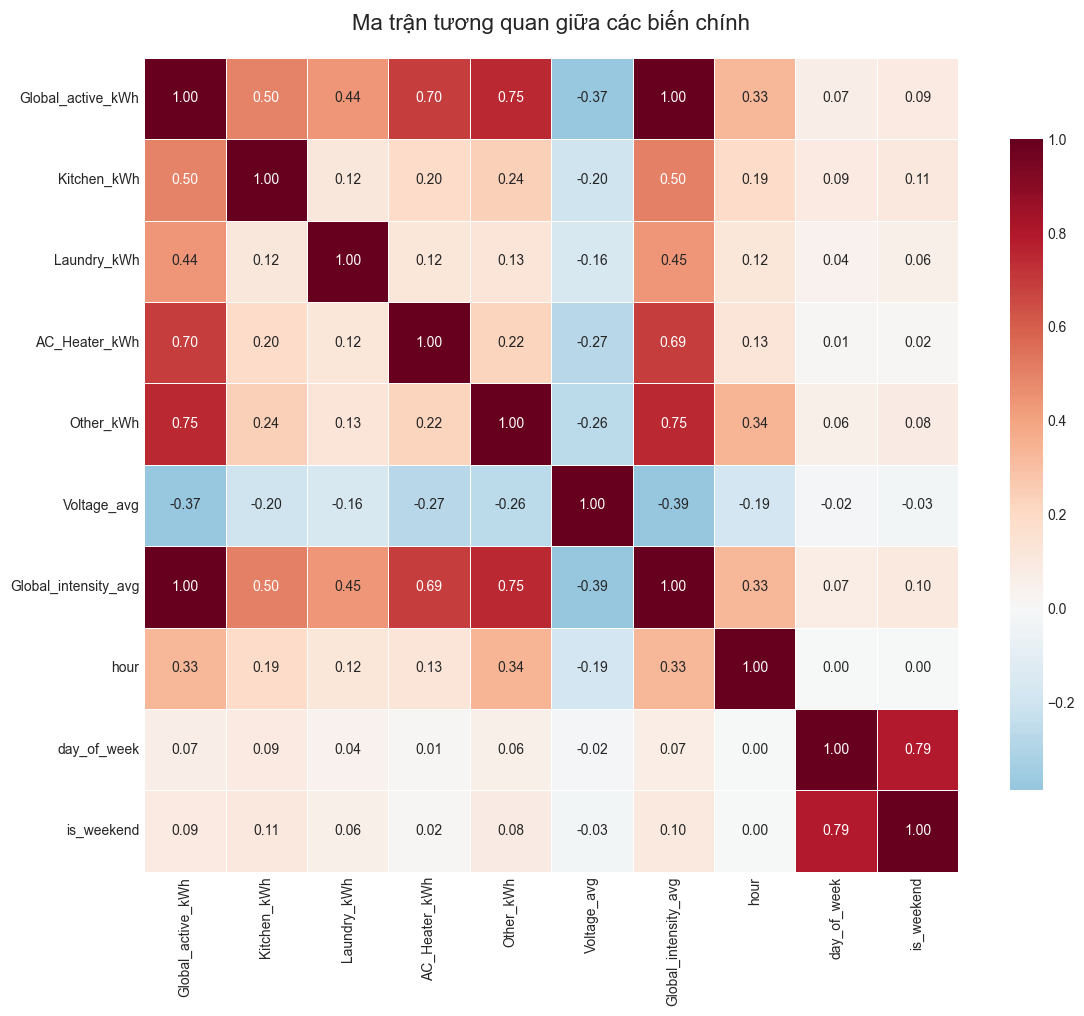


📈 CORRELATION ANALYSIS:
--------------------------------------------------
Tìm thấy 7 cặp biến có |correlation| > 0.5:
  Global_active_kWh ↔ AC_Heater_kWh: 0.696
  Global_active_kWh ↔ Other_kWh: 0.754
  Global_active_kWh ↔ Global_intensity_avg: 0.999
  Kitchen_kWh ↔ Global_intensity_avg: 0.504
  AC_Heater_kWh ↔ Global_intensity_avg: 0.686
  Other_kWh ↔ Global_intensity_avg: 0.755
  day_of_week ↔ is_weekend: 0.791


⏰ HOURLY PATTERN ANALYSIS:

Thống kê tiêu thụ theo giờ (trung bình):
hour
0    0.663
1    0.545
2    0.487
3    0.452
4    0.451
Name: mean, dtype: float64


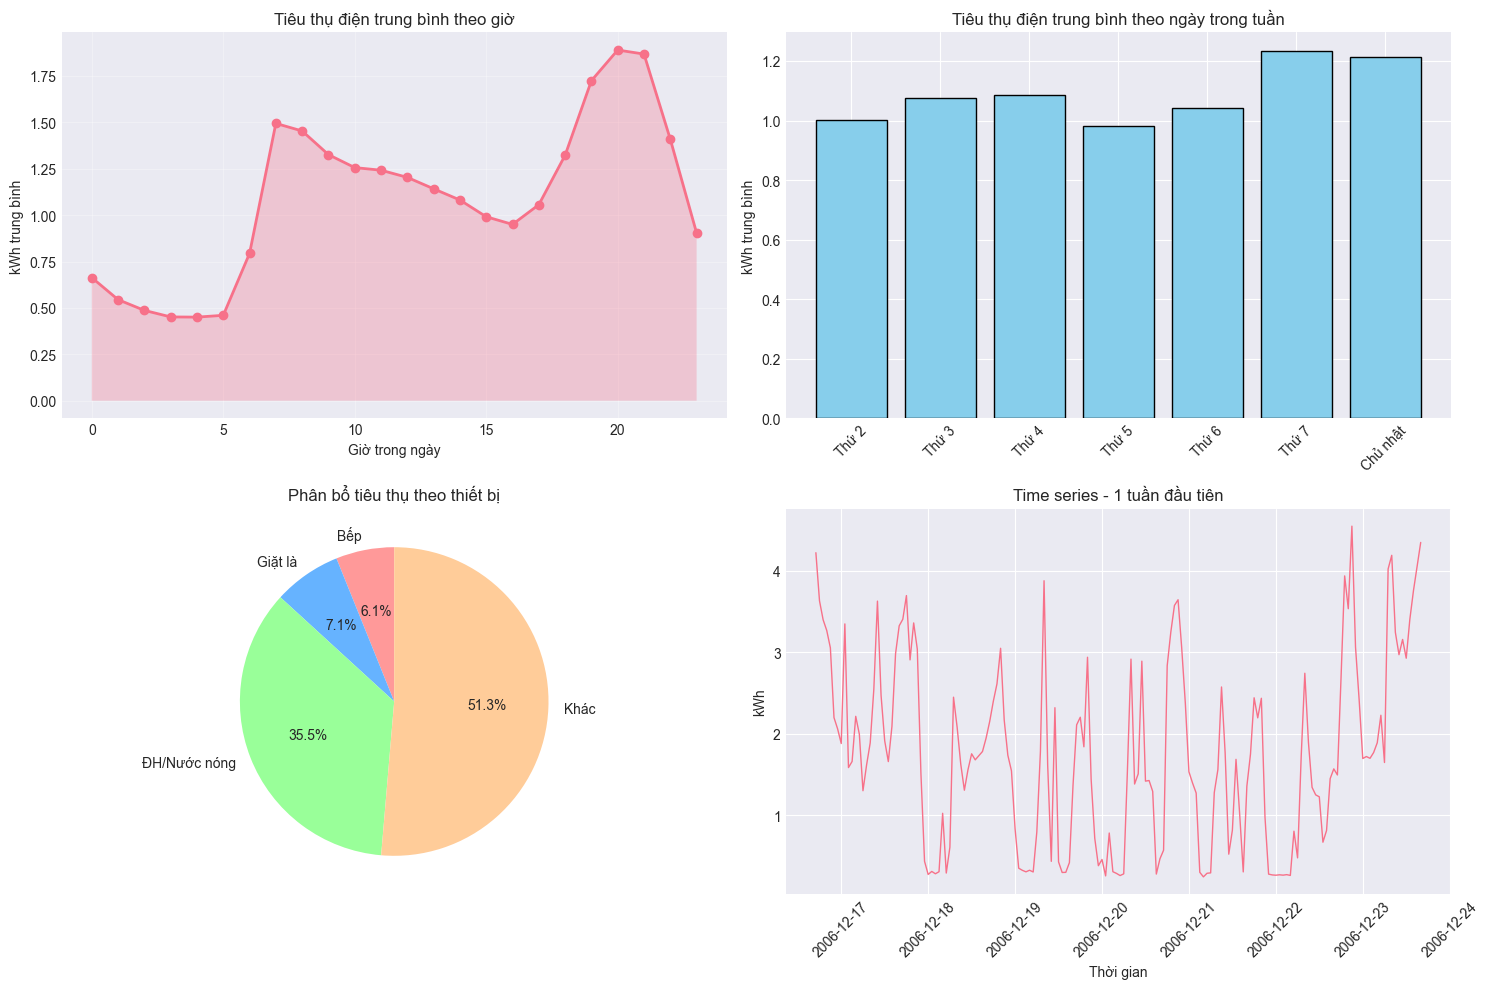


✅ Đã hoàn thành phân tích sơ bộ
📁 Đã lưu hình ảnh: correlation_matrix.png và preliminary_analysis.png


In [23]:
print("PHÂN TÍCH TƯƠNG QUAN SƠ BỘ")

# Tính correlation matrix cho các biến chính
corr_columns = ['Global_active_kWh', 'Kitchen_kWh', 'Laundry_kWh', 
                'AC_Heater_kWh', 'Other_kWh', 'Voltage_avg', 
                'Global_intensity_avg', 'hour', 'day_of_week', 'is_weekend']

corr_matrix = df_hourly[corr_columns].corr()

# Vẽ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các biến chính', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Phân tích correlation mạnh
print("\n📈 CORRELATION ANALYSIS:")
print("-" * 50)

# Tìm correlations mạnh (|r| > 0.5)
strong_corrs = []
for i in range(len(corr_columns)):
    for j in range(i+1, len(corr_columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            strong_corrs.append({
                'var1': corr_columns[i],
                'var2': corr_columns[j],
                'correlation': corr_value
            })

print(f"Tìm thấy {len(strong_corrs)} cặp biến có |correlation| > 0.5:")
for corr in strong_corrs[:10]:  # Hiển thị 10 cặp đầu
    print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")

# Phân tích theo giờ
print("\n\n⏰ HOURLY PATTERN ANALYSIS:")
hourly_stats = df_hourly.groupby('hour').agg({
    'Global_active_kWh': ['mean', 'std', 'min', 'max'],
    'AC_Heater_kWh': 'mean',
    'Kitchen_kWh': 'mean'
}).round(3)

print("\nThống kê tiêu thụ theo giờ (trung bình):")
print(hourly_stats['Global_active_kWh']['mean'].head())

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Tiêu thụ theo giờ
hourly_avg = df_hourly.groupby('hour')['Global_active_kWh'].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
axes[0, 0].fill_between(hourly_avg.index, 0, hourly_avg.values, alpha=0.3)
axes[0, 0].set_title('Tiêu thụ điện trung bình theo giờ', fontsize=12)
axes[0, 0].set_xlabel('Giờ trong ngày')
axes[0, 0].set_ylabel('kWh trung bình')
axes[0, 0].grid(True, alpha=0.3)

# 2. Tiêu thụ theo ngày trong tuần
weekday_avg = df_hourly.groupby('day_of_week')['Global_active_kWh'].mean()
weekday_labels = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ nhật']
axes[0, 1].bar(weekday_labels, weekday_avg.values, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Tiêu thụ điện trung bình theo ngày trong tuần', fontsize=12)
axes[0, 1].set_ylabel('kWh trung bình')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Phân bổ thiết bị
device_consumption = df_hourly[['Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh']].sum()
device_labels = ['Bếp', 'Giặt là', 'ĐH/Nước nóng', 'Khác']
axes[1, 0].pie(device_consumption.values, labels=device_labels, autopct='%1.1f%%',
               startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1, 0].set_title('Phân bổ tiêu thụ theo thiết bị', fontsize=12)

# 4. Time series sample (1 tuần)
sample_data = df_hourly['Global_active_kWh'].iloc[:168]  # 1 tuần đầu
axes[1, 1].plot(sample_data.index, sample_data.values, linewidth=1)
axes[1, 1].set_title('Time series - 1 tuần đầu tiên', fontsize=12)
axes[1, 1].set_xlabel('Thời gian')
axes[1, 1].set_ylabel('kWh')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('preliminary_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Đã hoàn thành phân tích sơ bộ")
print("📁 Đã lưu hình ảnh: correlation_matrix.png và preliminary_analysis.png")

TẢI DỮ LIỆU VÀ THIẾT LẬP

In [24]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
import calendar
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
import json
from datetime import datetime

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Tải dữ liệu đã làm sạch
df_hourly = pd.read_csv('household_power_cleaned_hourly.csv', 
                         parse_dates=True, index_col='DateTime')
df_minute = pd.read_csv('household_power_cleaned_minute.csv',
                        parse_dates=True, index_col='DateTime')

print(f"📊 DỮ LIỆU ĐÃ TẢI:")
print(f"- Hourly data: {df_hourly.shape[0]} dòng, {df_hourly.shape[1]} cột")
print(f"- Minute data: {df_minute.shape[0]} dòng, {df_minute.shape[1]} cột")
print(f"- Thời gian: {df_hourly.index.min()} đến {df_hourly.index.max()}")

📊 DỮ LIỆU ĐÃ TẢI:
- Hourly data: 34589 dòng, 85 cột
- Minute data: 2075259 dòng, 7 cột
- Thời gian: 2006-12-16 17:00:00 đến 2010-11-26 21:00:00


PHÂN TÍCH CHI TIẾT THEO THỜI GIAN

📈 PHÂN TÍCH CHI TIẾT THEO THỜI GIAN


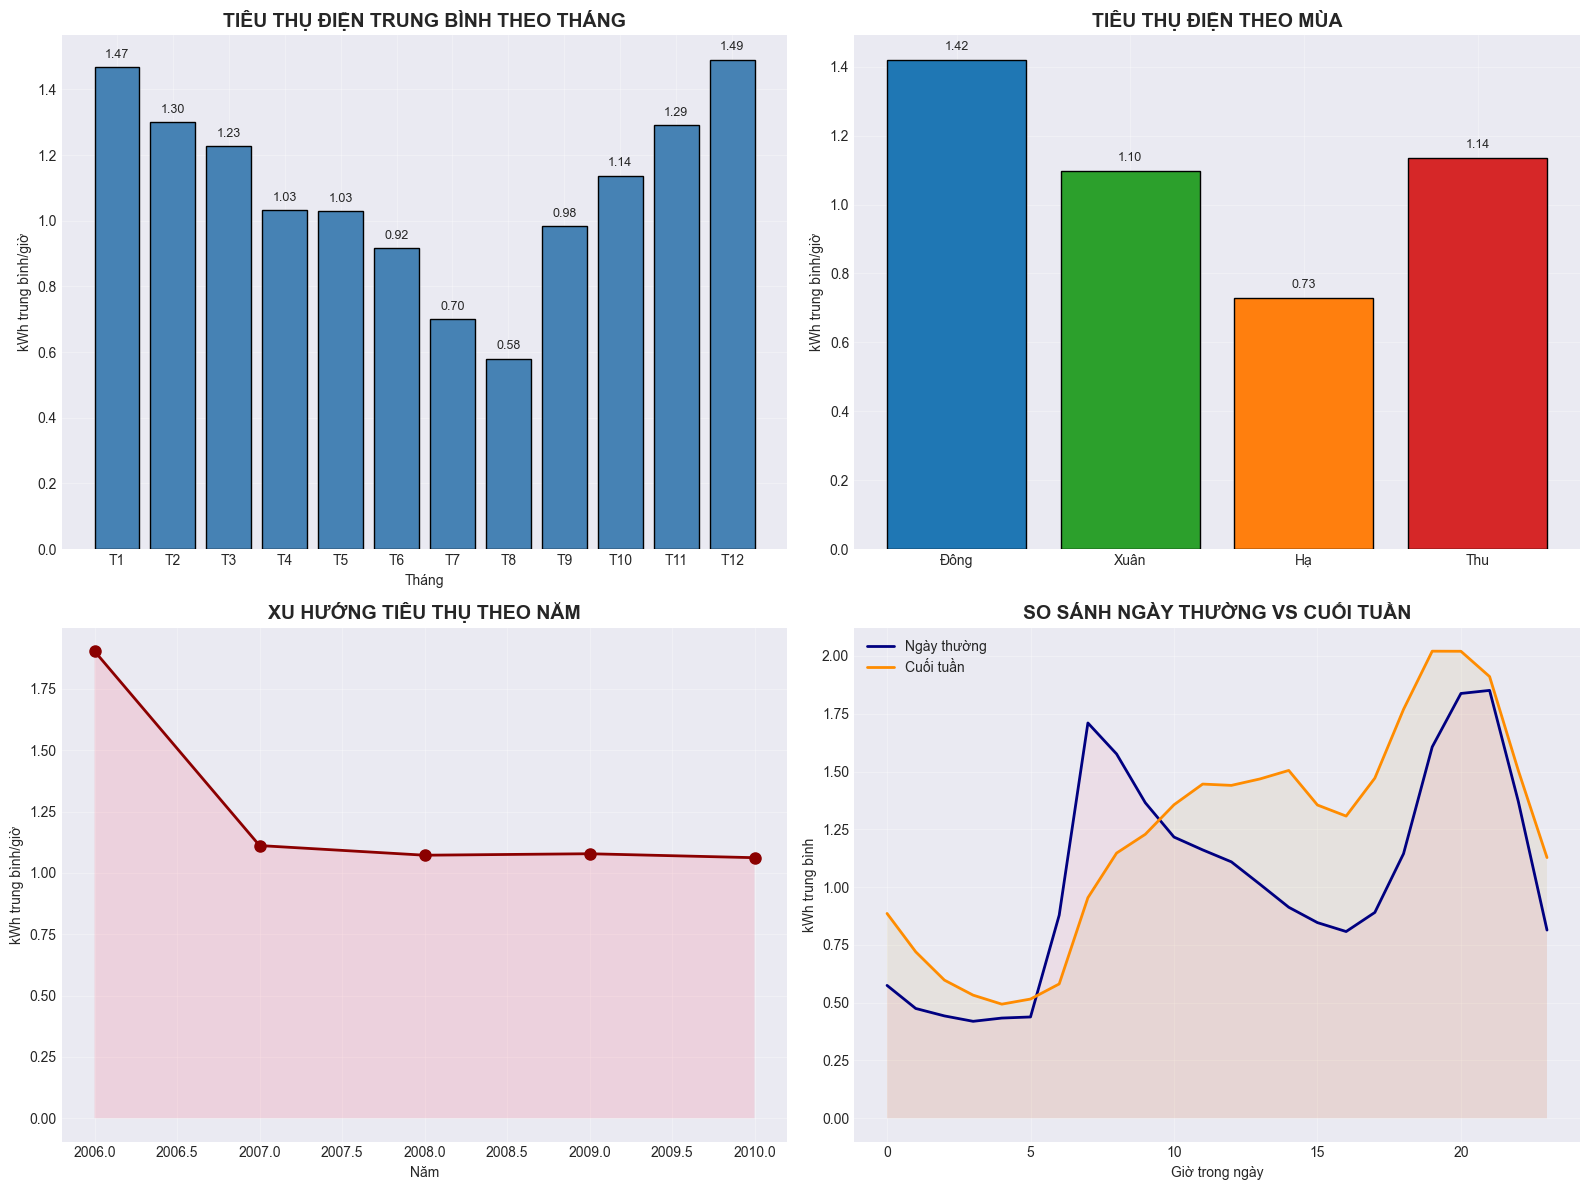


📊 THỐNG KÊ THEO MÙA:
  Đông: 1.420 kWh/giờ (Min: 0.244, Max: 6.520)
  Xuân: 1.097 kWh/giờ (Min: 0.163, Max: 5.671)
  Hạ: 0.730 kWh/giờ (Min: 0.124, Max: 4.634)
  Thu: 1.136 kWh/giờ (Min: 0.149, Max: 6.561)

📊 XU HƯỚNG THEO NĂM:
  Năm 2006: 1.904 kWh/giờ (698.8 kWh tổng)
  Năm 2007: 1.112 kWh/giờ (9738.3 kWh tổng)
  Năm 2008: 1.072 kWh/giờ (9419.2 kWh tổng)
  Năm 2009: 1.078 kWh/giờ (9446.0 kWh tổng)
  Năm 2010: 1.062 kWh/giờ (8410.6 kWh tổng)


In [25]:

print("📈 PHÂN TÍCH CHI TIẾT THEO THỜI GIAN")
print("="*50)

# 1. Phân tích theo mùa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# a) Tiêu thụ theo tháng
monthly_consumption = df_hourly.groupby('month')['Global_active_kWh'].mean()
axes[0, 0].bar(monthly_consumption.index, monthly_consumption.values, 
               color='steelblue', edgecolor='black')
axes[0, 0].set_title('TIÊU THỤ ĐIỆN TRUNG BÌNH THEO THÁNG', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Tháng')
axes[0, 0].set_ylabel('kWh trung bình/giờ')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 
                           'T7', 'T8', 'T9', 'T10', 'T11', 'T12'])
axes[0, 0].grid(True, alpha=0.3)

# Thêm nhãn giá trị
for i, v in enumerate(monthly_consumption.values):
    axes[0, 0].text(i+1, v+0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# b) Tiêu thụ theo mùa
seasonal_consumption = df_hourly.groupby('season')['Global_active_kWh'].mean()
season_labels = ['Đông', 'Xuân', 'Hạ', 'Thu']
axes[0, 1].bar(season_labels, seasonal_consumption.values, 
               color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'], edgecolor='black')
axes[0, 1].set_title('TIÊU THỤ ĐIỆN THEO MÙA', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('kWh trung bình/giờ')
axes[0, 1].grid(True, alpha=0.3)

for i, v in enumerate(seasonal_consumption.values):
    axes[0, 1].text(i, v+0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# c) Tiêu thụ theo năm
yearly_consumption = df_hourly.groupby('year')['Global_active_kWh'].mean()
axes[1, 0].plot(yearly_consumption.index, yearly_consumption.values, 
                marker='o', linewidth=2, markersize=8, color='darkred')
axes[1, 0].fill_between(yearly_consumption.index, 0, yearly_consumption.values, alpha=0.2)
axes[1, 0].set_title('XU HƯỚNG TIÊU THỤ THEO NĂM', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Năm')
axes[1, 0].set_ylabel('kWh trung bình/giờ')
axes[1, 0].grid(True, alpha=0.3)

# d) Phân tích weekend vs weekday chi tiết
weekday_weekend = df_hourly.groupby(['is_weekend', 'hour'])['Global_active_kWh'].mean().unstack(0)
weekday_weekend.columns = ['Weekday', 'Weekend']
axes[1, 1].plot(weekday_weekend.index, weekday_weekend['Weekday'], 
                label='Ngày thường', linewidth=2, color='navy')
axes[1, 1].plot(weekday_weekend.index, weekday_weekend['Weekend'], 
                label='Cuối tuần', linewidth=2, color='darkorange')
axes[1, 1].fill_between(weekday_weekend.index, 0, weekday_weekend['Weekday'], alpha=0.1)
axes[1, 1].fill_between(weekday_weekend.index, 0, weekday_weekend['Weekend'], alpha=0.1)
axes[1, 1].set_title('SO SÁNH NGÀY THƯỜNG VS CUỐI TUẦN', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Giờ trong ngày')
axes[1, 1].set_ylabel('kWh trung bình')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('seasonal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Thống kê chi tiết
print("\n📊 THỐNG KÊ THEO MÙA:")
for season, label in enumerate(season_labels, 1):
    season_data = df_hourly[df_hourly['season'] == season]['Global_active_kWh']
    print(f"  {label}: {season_data.mean():.3f} kWh/giờ (Min: {season_data.min():.3f}, Max: {season_data.max():.3f})")

print(f"\n📊 XU HƯỚNG THEO NĂM:")
for year, cons in yearly_consumption.items():
    year_data = df_hourly[df_hourly['year'] == year]['Global_active_kWh']
    print(f"  Năm {year}: {cons:.3f} kWh/giờ ({year_data.sum():.1f} kWh tổng)")

PHÂN TÍCH THIẾT BỊ CHI TIẾT

🔌 PHÂN TÍCH THIẾT BỊ CHI TIẾT


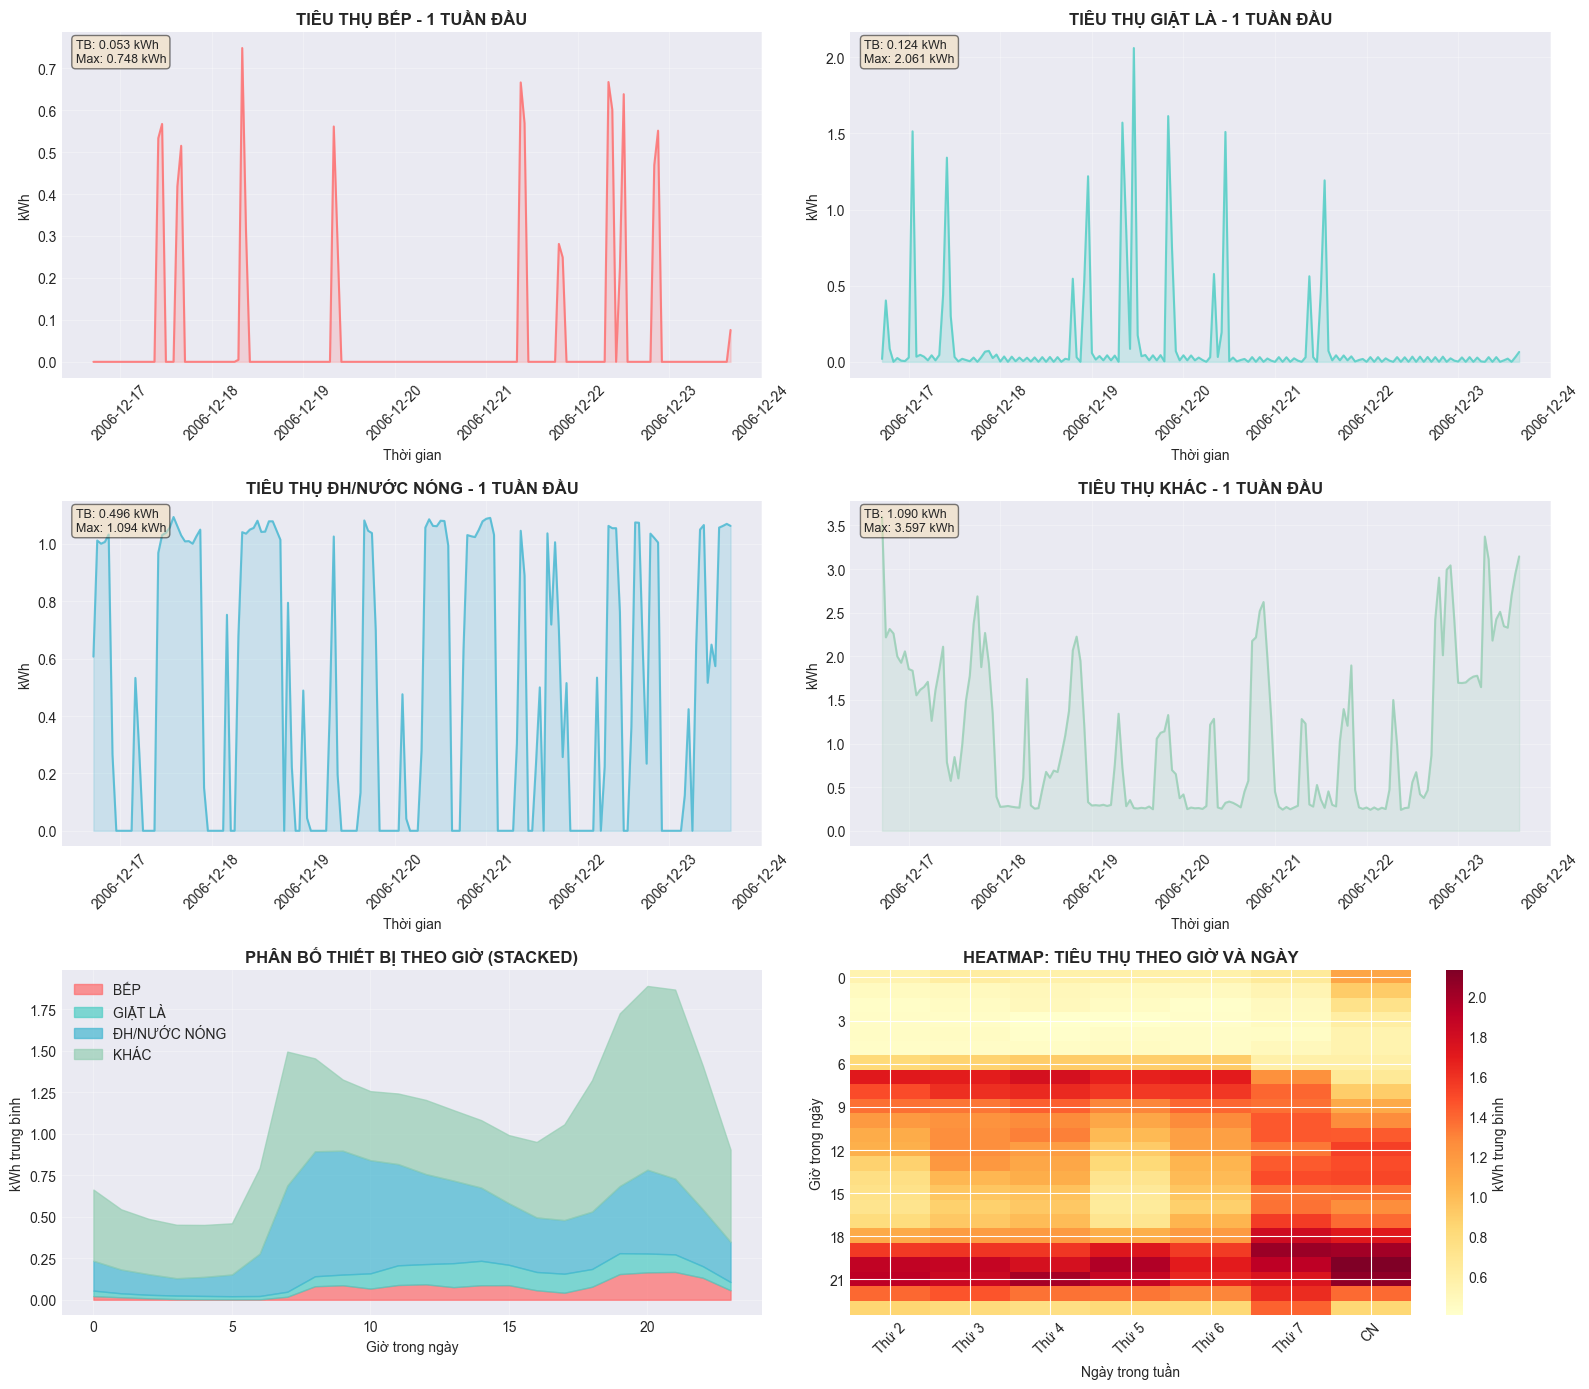


📊 THỐNG KÊ TIÊU THỤ THIẾT BỊ:

BẾP:
  • Tổng tiêu thụ: 2302.5 kWh (6.1%)
  • Trung bình/giờ: 0.067 kWh
  • Giờ cao điểm trung bình: 0.122 kWh
  • Giá trị cao nhất: 2.902 kWh

GIẶT LÀ:
  • Tổng tiêu thụ: 2675.5 kWh (7.1%)
  • Trung bình/giờ: 0.077 kWh
  • Giờ cao điểm trung bình: 0.113 kWh
  • Giá trị cao nhất: 2.786 kWh

ĐH/NƯỚC NÓNG:
  • Tổng tiêu thụ: 13369.6 kWh (35.5%)
  • Trung bình/giờ: 0.387 kWh
  • Giờ cao điểm trung bình: 0.407 kWh
  • Giá trị cao nhất: 1.471 kWh

KHÁC:
  • Tổng tiêu thụ: 19365.2 kWh (51.3%)
  • Trung bình/giờ: 0.560 kWh
  • Giờ cao điểm trung bình: 0.931 kWh
  • Giá trị cao nhất: 3.890 kWh


In [26]:

print("🔌 PHÂN TÍCH THIẾT BỊ CHI TIẾT")
print("="*50)

# Tạo figure lớn
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Danh sách thiết bị
devices = ['Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh']
device_names = ['BẾP', 'GIẶT LÀ', 'ĐH/NƯỚC NÓNG', 'KHÁC']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# 1. Time series cho từng thiết bị (1 tuần đầu)
sample_days = 7 * 24  # 7 ngày
for idx, (device, name, color) in enumerate(zip(devices, device_names, colors)):
    row = idx // 2
    col = idx % 2
    
    # Lấy mẫu 1 tuần đầu
    device_data = df_hourly[device].iloc[:sample_days]
    
    axes[row, col].plot(device_data.index, device_data.values, 
                       linewidth=1.5, color=color, alpha=0.8)
    axes[row, col].fill_between(device_data.index, 0, device_data.values, 
                               alpha=0.2, color=color)
    axes[row, col].set_title(f'TIÊU THỤ {name} - 1 TUẦN ĐẦU', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Thời gian')
    axes[row, col].set_ylabel('kWh')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(True, alpha=0.3)
    
    # Thêm thống kê
    stats_text = f'TB: {device_data.mean():.3f} kWh\nMax: {device_data.max():.3f} kWh'
    axes[row, col].text(0.02, 0.98, stats_text, transform=axes[row, col].transAxes,
                       fontsize=9, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Phân bố thiết bị theo giờ (ở ô cuối)
device_hourly = pd.DataFrame()
for device in devices:
    device_hourly[device] = df_hourly.groupby('hour')[device].mean()

# Vẽ stacked area chart
hours = range(24)
bottom = np.zeros(24)
for idx, (device, name, color) in enumerate(zip(devices, device_names, colors)):
    values = device_hourly[device].values
    axes[2, 0].fill_between(hours, bottom, bottom + values, 
                           label=name, color=color, alpha=0.7)
    bottom += values

axes[2, 0].set_title('PHÂN BỐ THIẾT BỊ THEO GIỜ (STACKED)', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Giờ trong ngày')
axes[2, 0].set_ylabel('kWh trung bình')
axes[2, 0].legend(loc='upper left')
axes[2, 0].grid(True, alpha=0.3)

# 3. Heatmap tiêu thụ theo giờ và ngày
hour_day_matrix = df_hourly.pivot_table(values='Global_active_kWh', 
                                       index='hour', 
                                       columns='day_of_week',
                                       aggfunc='mean')

# Đổi tên cột
day_names = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'CN']
hour_day_matrix.columns = day_names

im = axes[2, 1].imshow(hour_day_matrix.values, cmap='YlOrRd', aspect='auto', 
                      interpolation='nearest')
axes[2, 1].set_title('HEATMAP: TIÊU THỤ THEO GIỜ VÀ NGÀY', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Ngày trong tuần')
axes[2, 1].set_ylabel('Giờ trong ngày')
axes[2, 1].set_xticks(range(len(day_names)))
axes[2, 1].set_xticklabels(day_names, rotation=45)
axes[2, 1].set_yticks(range(0, 24, 3))
axes[2, 1].set_yticklabels(range(0, 24, 3))

# Thêm colorbar
cbar = plt.colorbar(im, ax=axes[2, 1])
cbar.set_label('kWh trung bình')

plt.tight_layout()
plt.savefig('device_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Thống kê thiết bị chi tiết
print("\n📊 THỐNG KÊ TIÊU THỤ THIẾT BỊ:")
total_global = df_hourly['Global_active_kWh'].sum()
for device, name in zip(devices, device_names):
    device_total = df_hourly[device].sum()
    percentage = (device_total / total_global) * 100
    device_mean = df_hourly[device].mean()
    device_max = df_hourly[device].max()
    
    print(f"\n{name}:")
    print(f"  • Tổng tiêu thụ: {device_total:.1f} kWh ({percentage:.1f}%)")
    print(f"  • Trung bình/giờ: {device_mean:.3f} kWh")
    print(f"  • Giờ cao điểm trung bình: {df_hourly[df_hourly['is_peak_hour']==1][device].mean():.3f} kWh")
    print(f"  • Giá trị cao nhất: {device_max:.3f} kWh")

PHÂN TÍCH TƯƠNG QUAN NÂNG CAO

🔗 PHÂN TÍCH TƯƠNG QUAN NÂNG CAO


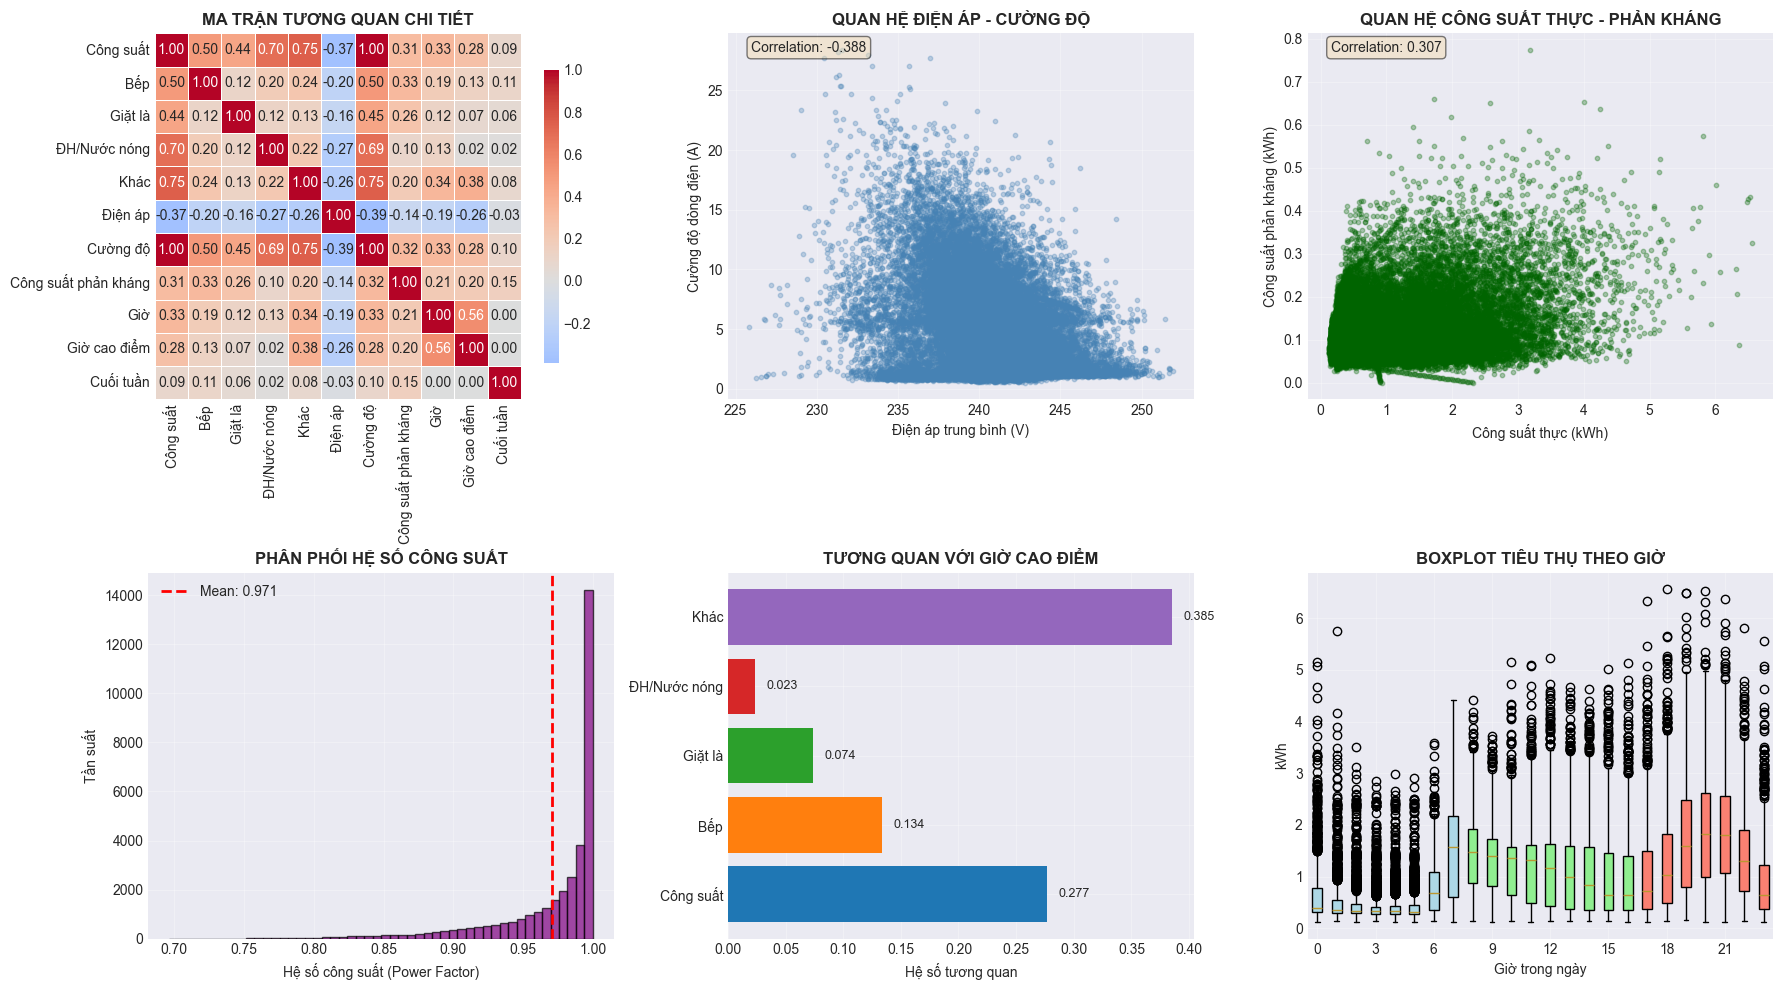


🔍 PHÂN TÍCH TƯƠNG QUAN MẠNH (|r| > 0.5):
           Biến 1               Biến 2  Correlation
Global_active_kWh Global_intensity_avg     0.999419
        Other_kWh Global_intensity_avg     0.754722
Global_active_kWh            Other_kWh     0.754376
Global_active_kWh        AC_Heater_kWh     0.696029
    AC_Heater_kWh Global_intensity_avg     0.686243
             hour         is_peak_hour     0.555914
      Kitchen_kWh Global_intensity_avg     0.504097


In [ ]:

print("🔗 PHÂN TÍCH TƯƠNG QUAN NÂNG CAO")
print("="*50)

# Tạo figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Correlation matrix chi tiết (chỉ các biến chính)
corr_columns = ['Global_active_kWh', 'Kitchen_kWh', 'Laundry_kWh', 
                'AC_Heater_kWh', 'Other_kWh', 'Voltage_avg', 
                'Global_intensity_avg', 'Global_reactive_kWh',
                'hour', 'is_peak_hour', 'is_weekend']

corr_matrix = df_hourly[corr_columns].corr()

# Đổi tên cột cho dễ đọc
rename_dict = {
    'Global_active_kWh': 'Công suất',
    'Kitchen_kWh': 'Bếp',
    'Laundry_kWh': 'Giặt là',
    'AC_Heater_kWh': 'ĐH/Nước nóng',
    'Other_kWh': 'Khác',
    'Voltage_avg': 'Điện áp',
    'Global_intensity_avg': 'Cường độ',
    'Global_reactive_kWh': 'Công suất phản kháng',
    'hour': 'Giờ',
    'is_peak_hour': 'Giờ cao điểm',
    'is_weekend': 'Cuối tuần'
}

corr_matrix_renamed = corr_matrix.rename(columns=rename_dict, index=rename_dict)

# Vẽ heatmap
sns.heatmap(corr_matrix_renamed, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, ax=axes[0, 0],
            cbar_kws={"shrink": 0.8})
axes[0, 0].set_title('MA TRẬN TƯƠNG QUAN CHI TIẾT', fontsize=12, fontweight='bold')

# 2. Scatter plot: Voltage vs Intensity
axes[0, 1].scatter(df_hourly['Voltage_avg'], df_hourly['Global_intensity_avg'], 
                  alpha=0.3, s=10, color='steelblue')
axes[0, 1].set_xlabel('Điện áp trung bình (V)')
axes[0, 1].set_ylabel('Cường độ dòng điện (A)')
axes[0, 1].set_title('QUAN HỆ ĐIỆN ÁP - CƯỜNG ĐỘ', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Tính correlation
voltage_intensity_corr = df_hourly['Voltage_avg'].corr(df_hourly['Global_intensity_avg'])
axes[0, 1].text(0.05, 0.95, f'Correlation: {voltage_intensity_corr:.3f}', 
                transform=axes[0, 1].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Scatter plot: Active vs Reactive Power
axes[0, 2].scatter(df_hourly['Global_active_kWh'], df_hourly['Global_reactive_kWh'], 
                  alpha=0.3, s=10, color='darkgreen')
axes[0, 2].set_xlabel('Công suất thực (kWh)')
axes[0, 2].set_ylabel('Công suất phản kháng (kWh)')
axes[0, 2].set_title('QUAN HỆ CÔNG SUẤT THỰC - PHẢN KHÁNG', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

active_reactive_corr = df_hourly['Global_active_kWh'].corr(df_hourly['Global_reactive_kWh'])
axes[0, 2].text(0.05, 0.95, f'Correlation: {active_reactive_corr:.3f}', 
                transform=axes[0, 2].transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Phân tích Power Factor
df_hourly['power_factor'] = df_hourly['Global_active_kWh'] / np.sqrt(
    df_hourly['Global_active_kWh']**2 + df_hourly['Global_reactive_kWh']**2)

axes[1, 0].hist(df_hourly['power_factor'].dropna(), bins=50, 
               color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(df_hourly['power_factor'].mean(), color='red', 
                  linestyle='--', linewidth=2, label=f'Mean: {df_hourly["power_factor"].mean():.3f}')
axes[1, 0].set_xlabel('Hệ số công suất (Power Factor)')
axes[1, 0].set_ylabel('Tần suất')
axes[1, 0].set_title('PHÂN PHỐI HỆ SỐ CÔNG SUẤT', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Correlation với giờ cao điểm
peak_hour_corr = {}
for col in ['Global_active_kWh', 'Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh']:
    peak_hour_corr[col] = df_hourly[col].corr(df_hourly['is_peak_hour'])

peak_df = pd.DataFrame.from_dict(peak_hour_corr, orient='index', columns=['Correlation'])
peak_df.index = ['Công suất', 'Bếp', 'Giặt là', 'ĐH/Nước nóng', 'Khác']

axes[1, 1].barh(peak_df.index, peak_df['Correlation'].values, 
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
axes[1, 1].set_xlabel('Hệ số tương quan')
axes[1, 1].set_title('TƯƠNG QUAN VỚI GIỜ CAO ĐIỂM', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Thêm giá trị trên bars
for i, v in enumerate(peak_df['Correlation'].values):
    axes[1, 1].text(v + 0.01 if v > 0 else v - 0.03, i, f'{v:.3f}', 
                   va='center', fontsize=9)

# 6. Boxplot theo giờ (Global Active Power)
hourly_boxplot_data = [df_hourly[df_hourly['hour'] == h]['Global_active_kWh'].values 
                       for h in range(24)]

bplot = axes[1, 2].boxplot(hourly_boxplot_data, patch_artist=True)
axes[1, 2].set_xlabel('Giờ trong ngày')
axes[1, 2].set_ylabel('kWh')
axes[1, 2].set_title('BOXPLOT TIÊU THỤ THEO GIỜ', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(range(1, 25, 3))
axes[1, 2].set_xticklabels(range(0, 24, 3))
axes[1, 2].grid(True, alpha=0.3)

# Tô màu cho boxplot
colors = ['lightblue' if i < 8 else 'lightgreen' if i < 17 else 'salmon' for i in range(24)]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Phân tích tương quan mạnh
print("\n🔍 PHÂN TÍCH TƯƠNG QUAN MẠNH (|r| > 0.5):")
strong_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            strong_correlations.append({
                'Biến 1': corr_columns[i],
                'Biến 2': corr_columns[j],
                'Correlation': corr_value
            })

strong_correlations_df = pd.DataFrame(strong_correlations)
if not strong_correlations_df.empty:
    print(strong_correlations_df.sort_values('Correlation', ascending=False).to_string(index=False))
else:
    print("Không có tương quan mạnh nào (|r| > 0.5)")

PHÂN TÍCH CHUỖI THỜI GIAN NÂNG CAO

⏰ PHÂN TÍCH CHUỖI THỜI GIAN NÂNG CAO

🔧 PHÂN TÍCH DECOMPOSITION (Trend, Seasonal, Residual)...


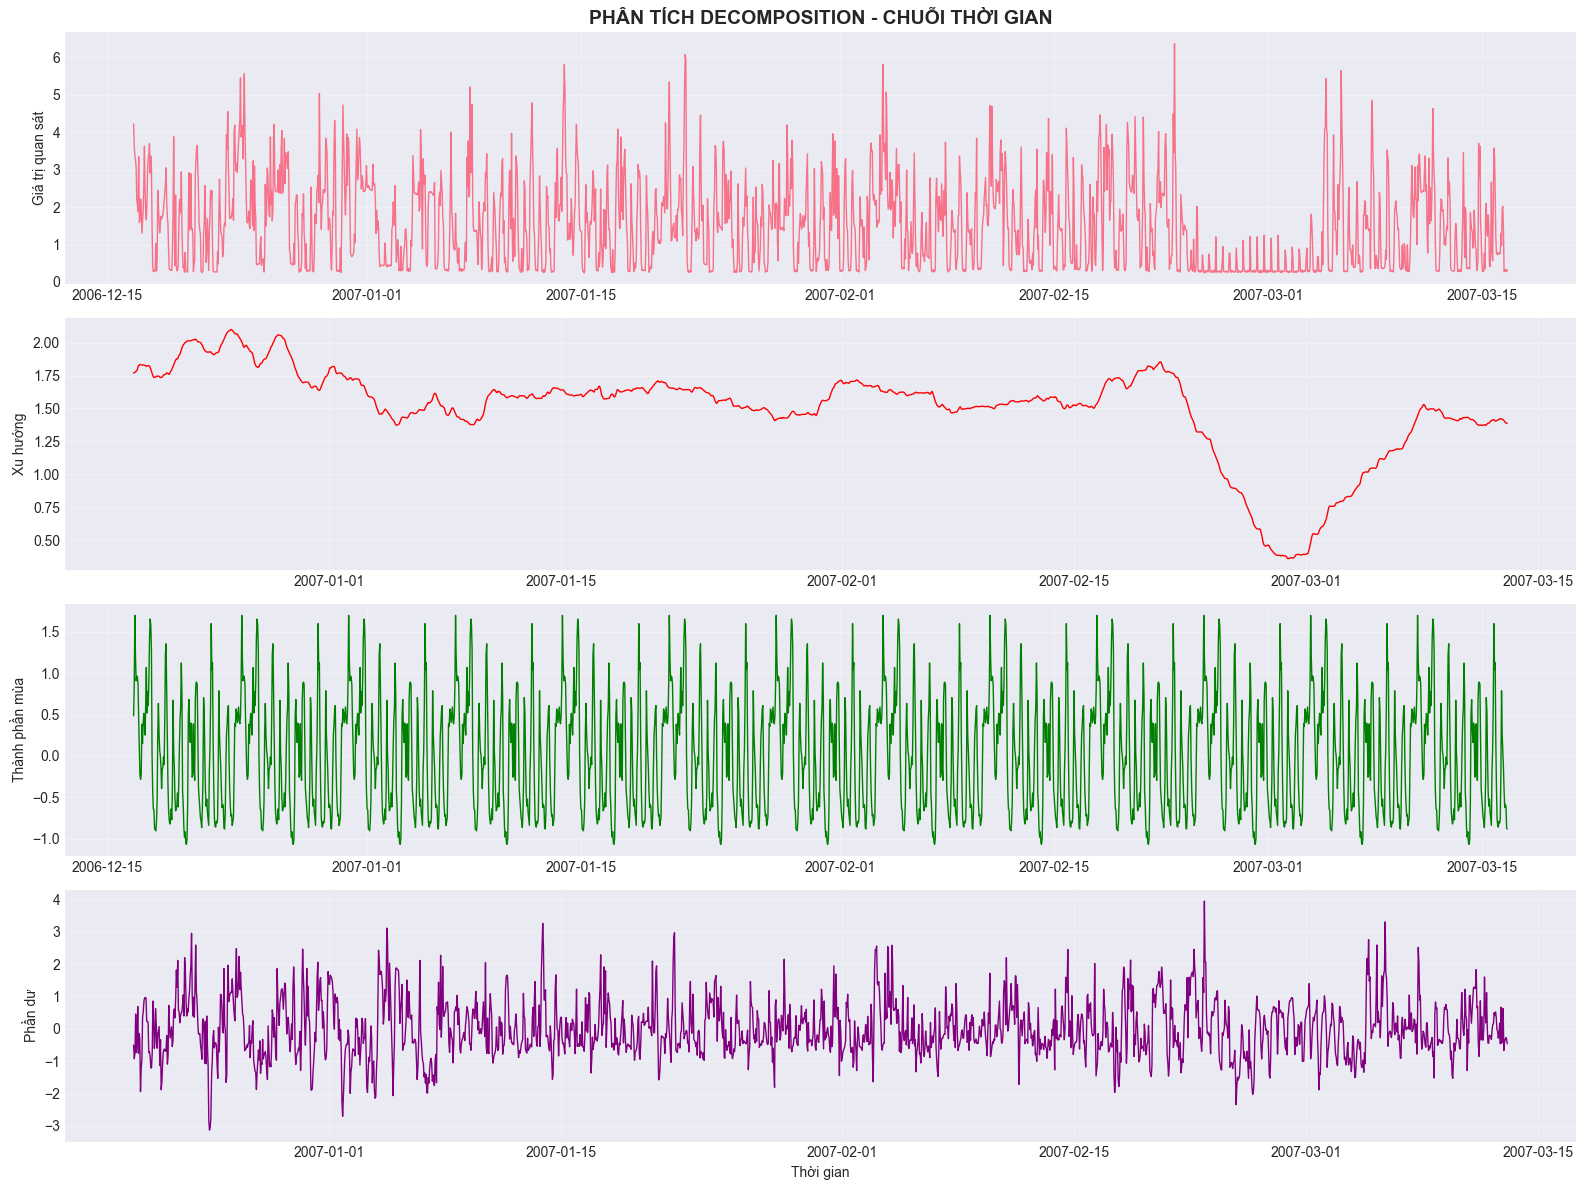


📊 PHÂN TÍCH ACF VÀ PACF...


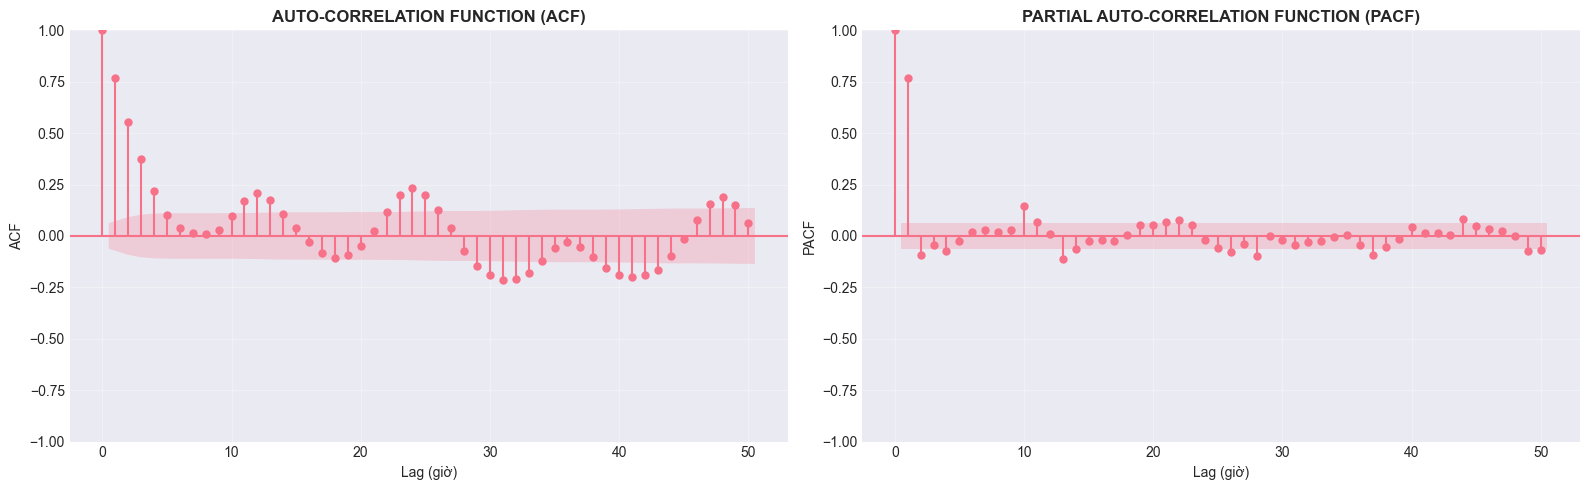


📈 PHÂN TÍCH ROLLING STATISTICS...


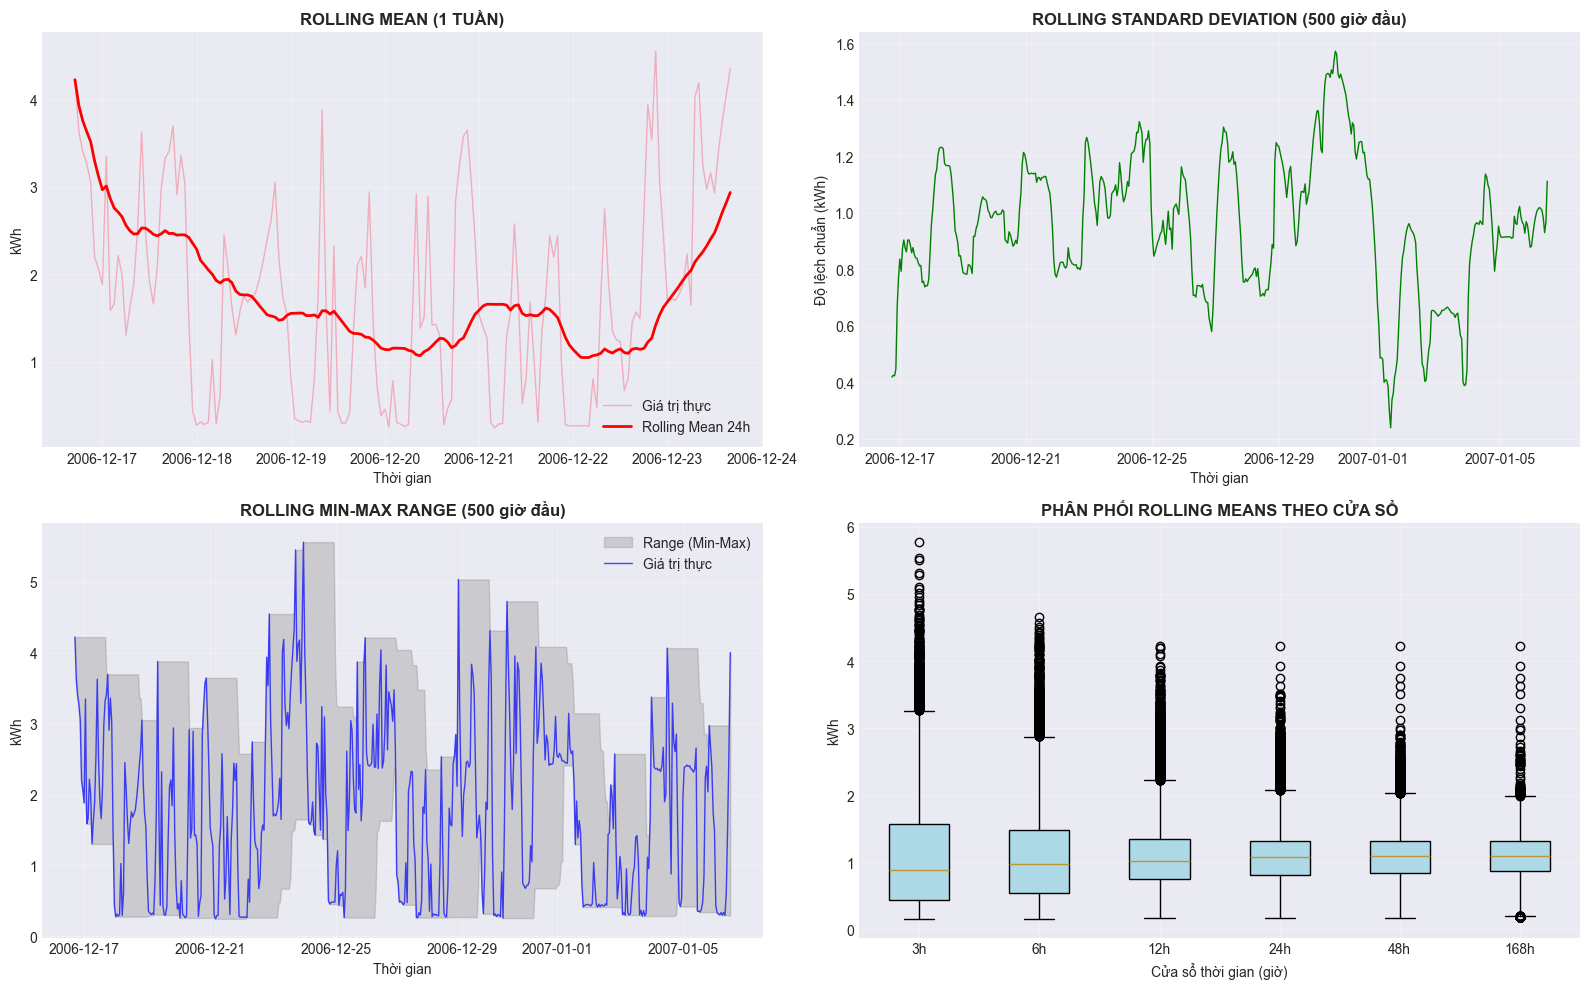

In [28]:

print("⏰ PHÂN TÍCH CHUỖI THỜI GIAN NÂNG CAO")
print("="*50)

# Chọn mẫu dữ liệu 3 tháng để phân tích (để tránh quá nặng)
sample_data = df_hourly['Global_active_kWh'].iloc[:2160]  # 90 ngày * 24 giờ

# 1. Seasonal Decomposition
print("\n🔧 PHÂN TÍCH DECOMPOSITION (Trend, Seasonal, Residual)...")
try:
    decomposition = seasonal_decompose(sample_data, model='additive', period=24*7)  # Weekly seasonality
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    
    # Original
    axes[0].plot(decomposition.observed, linewidth=1)
    axes[0].set_ylabel('Giá trị quan sát')
    axes[0].set_title('PHÂN TÍCH DECOMPOSITION - CHUỖI THỜI GIAN', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Trend
    axes[1].plot(decomposition.trend, linewidth=1, color='red')
    axes[1].set_ylabel('Xu hướng')
    axes[1].grid(True, alpha=0.3)
    
    # Seasonal
    axes[2].plot(decomposition.seasonal, linewidth=1, color='green')
    axes[2].set_ylabel('Thành phần mùa')
    axes[2].grid(True, alpha=0.3)
    
    # Residual
    axes[3].plot(decomposition.resid, linewidth=1, color='purple')
    axes[3].set_ylabel('Phần dư')
    axes[3].set_xlabel('Thời gian')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('time_series_decomposition.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"⚠️ Lỗi trong decomposition: {e}")

# 2. ACF và PACF
print("\n📊 PHÂN TÍCH ACF VÀ PACF...")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF (Auto-Correlation Function)
plot_acf(df_hourly['Global_active_kWh'].iloc[:1000], lags=50, ax=axes[0], alpha=0.05)
axes[0].set_title('AUTO-CORRELATION FUNCTION (ACF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (giờ)')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

# PACF (Partial Auto-Correlation Function)
plot_pacf(df_hourly['Global_active_kWh'].iloc[:1000], lags=50, ax=axes[1], alpha=0.05)
axes[1].set_title('PARTIAL AUTO-CORRELATION FUNCTION (PACF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (giờ)')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('acf_pacf_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Rolling statistics chi tiết
print("\n📈 PHÂN TÍCH ROLLING STATISTICS...")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Tính rolling statistics
rolling_24h = df_hourly['Global_active_kWh'].rolling(window=24, min_periods=1)
rolling_7d = df_hourly['Global_active_kWh'].rolling(window=24*7, min_periods=1)

# a) Rolling mean
sample_1week = df_hourly['Global_active_kWh'].iloc[:168]
rolling_24h_sample = sample_1week.rolling(window=24, min_periods=1).mean()

axes[0, 0].plot(sample_1week.index, sample_1week.values, alpha=0.5, label='Giá trị thực', linewidth=1)
axes[0, 0].plot(sample_1week.index, rolling_24h_sample.values, label='Rolling Mean 24h', 
               linewidth=2, color='red')
axes[0, 0].set_title('ROLLING MEAN (1 TUẦN)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Thời gian')
axes[0, 0].set_ylabel('kWh')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# b) Rolling std
rolling_std_24h = df_hourly['Global_active_kWh'].rolling(window=24, min_periods=1).std()
axes[0, 1].plot(rolling_std_24h.index[:500], rolling_std_24h.values[:500], 
               linewidth=1, color='green')
axes[0, 1].set_title('ROLLING STANDARD DEVIATION (500 giờ đầu)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Thời gian')
axes[0, 1].set_ylabel('Độ lệch chuẩn (kWh)')
axes[0, 1].grid(True, alpha=0.3)

# c) Rolling min/max
rolling_min = df_hourly['Global_active_kWh'].rolling(window=24, min_periods=1).min()
rolling_max = df_hourly['Global_active_kWh'].rolling(window=24, min_periods=1).max()

axes[1, 0].fill_between(df_hourly.index[:500], rolling_min[:500], rolling_max[:500], 
                        alpha=0.3, color='gray', label='Range (Min-Max)')
axes[1, 0].plot(df_hourly.index[:500], df_hourly['Global_active_kWh'].iloc[:500], 
               linewidth=1, color='blue', label='Giá trị thực', alpha=0.7)
axes[1, 0].set_title('ROLLING MIN-MAX RANGE (500 giờ đầu)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Thời gian')
axes[1, 0].set_ylabel('kWh')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# d) Distribution of rolling means
rolling_means = []
windows = [3, 6, 12, 24, 48, 168]  # 3h, 6h, 12h, 24h, 2d, 1w
for window in windows:
    rolling_mean = df_hourly['Global_active_kWh'].rolling(window=window, min_periods=1).mean()
    rolling_means.append(rolling_mean.dropna())

axes[1, 1].boxplot(rolling_means, labels=[f'{w}h' for w in windows], patch_artist=True)
axes[1, 1].set_title('PHÂN PHỐI ROLLING MEANS THEO CỬA SỔ', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cửa sổ thời gian (giờ)')
axes[1, 1].set_ylabel('kWh')
axes[1, 1].grid(True, alpha=0.3)

# Tô màu boxplot
for box in axes[1, 1].patches:
    box.set_facecolor('lightblue')

plt.tight_layout()
plt.savefig('rolling_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

PHÁT HIỆN ANOMALY VÀ OUTLIERS NÂNG CAO

🚨 PHÁT HIỆN ANOMALY VÀ OUTLIERS NÂNG CAO

📊 PHƯƠNG PHÁP Z-SCORE:
  • Ngưỡng Z-score: 3
  • Số điểm bất thường: 439 (1.27%)
  • Giá trị Z-score cao nhất: 6.12

📊 PHƯƠNG PHÁP IQR (THEO GIỜ):

  Top 5 giờ có nhiều outliers nhất:
   count  percentage
5    238   16.516308
4    231   16.030534
3    228   15.822346
2    221   15.336572
1    197   13.671062


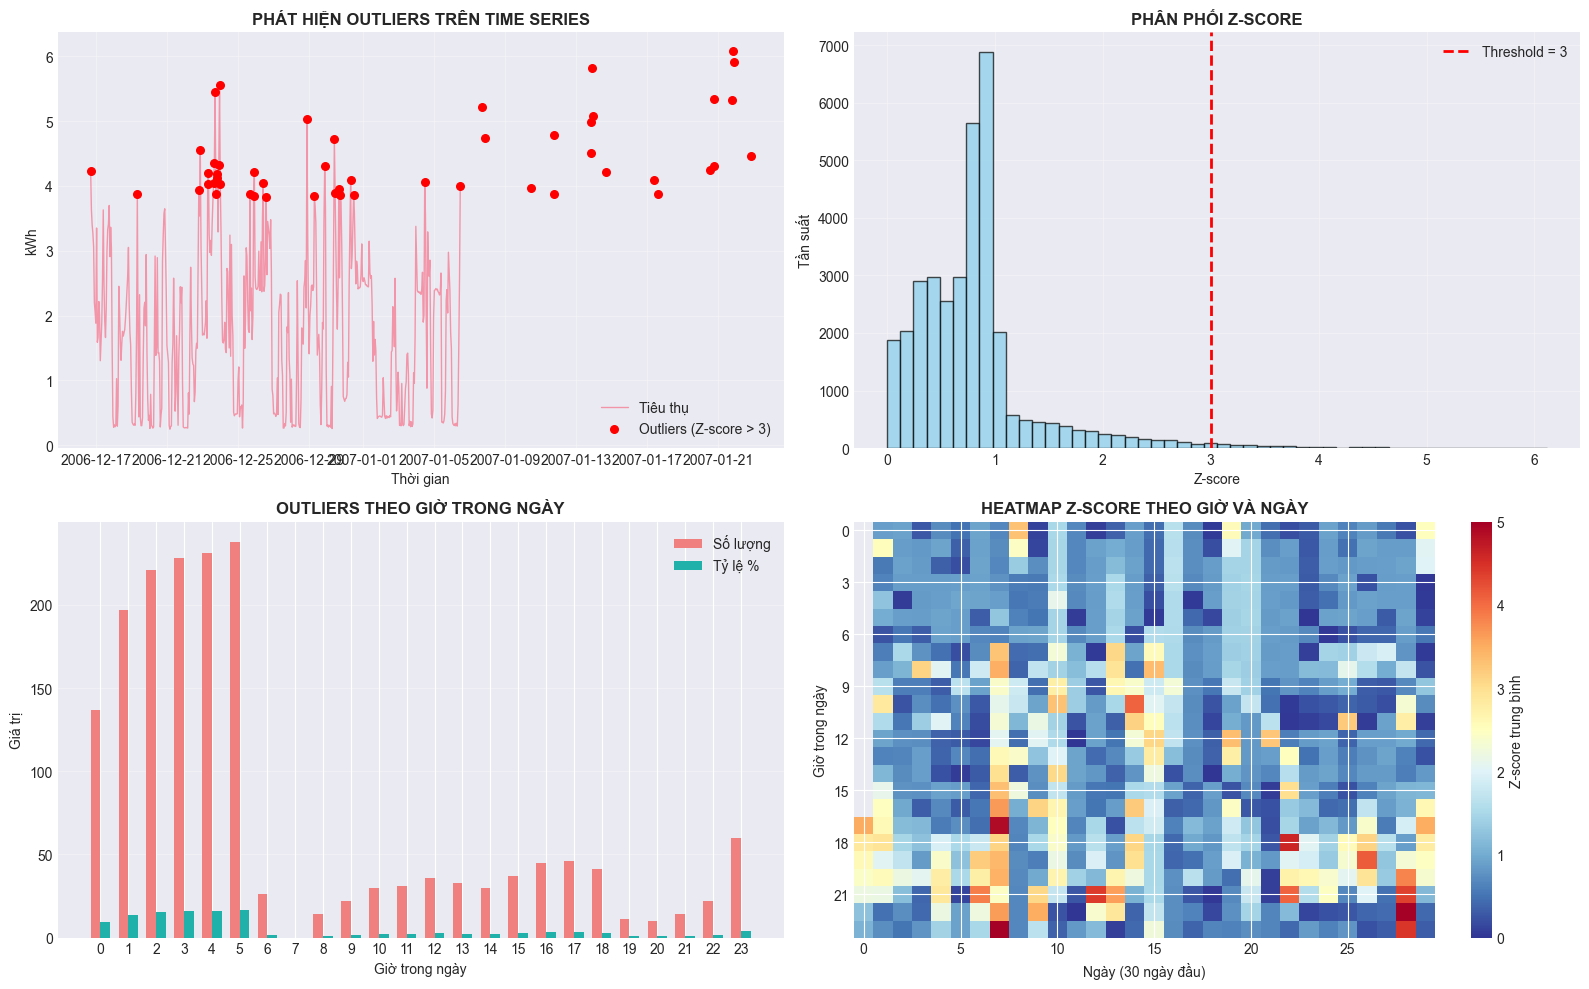


🔍 PHÂN TÍCH CHI TIẾT CÁC ĐIỂM ANOMALY:

  Top 10 điểm tiêu thụ cao nhất (có thể là anomaly):
    1. 2008-11-23 18:00:00: 6.561 kWh (Z-score: 6.12)
       • Giờ: 18h | Ngày: Sunday
       • Bếp: 0.000 | Giặt: 1.700 | ĐH: 0.988
    2. 2009-01-16 20:00:00: 6.520 kWh (Z-score: 6.07)
       • Giờ: 20h | Ngày: Friday
       • Bếp: 1.569 | Giặt: 1.692 | ĐH: 1.034
    3. 2008-02-02 19:00:00: 6.496 kWh (Z-score: 6.04)
       • Giờ: 19h | Ngày: Saturday
       • Bếp: 1.150 | Giặt: 1.842 | ĐH: 0.986
    4. 2007-12-23 19:00:00: 6.488 kWh (Z-score: 6.04)
       • Giờ: 19h | Ngày: Sunday
       • Bếp: 0.762 | Giặt: 2.294 | ĐH: 0.718
    5. 2007-02-22 21:00:00: 6.364 kWh (Z-score: 5.90)
       • Giờ: 21h | Ngày: Thursday
       • Bếp: 0.689 | Giặt: 1.964 | ĐH: 0.979
    6. 2007-12-28 17:00:00: 6.334 kWh (Z-score: 5.86)
       • Giờ: 17h | Ngày: Friday
       • Bếp: 0.000 | Giặt: 2.786 | ĐH: 1.023
    7. 2008-11-23 20:00:00: 6.311 kWh (Z-score: 5.84)
       • Giờ: 20h | Ngày: Sunday
       • Bếp: 0.4

In [29]:

print("🚨 PHÁT HIỆN ANOMALY VÀ OUTLIERS NÂNG CAO")
print("="*50)

# 1. Phương pháp Z-score
print("\n📊 PHƯƠNG PHÁP Z-SCORE:")
df_hourly['z_score'] = np.abs(stats.zscore(df_hourly['Global_active_kWh']))
z_score_threshold = 3
z_score_outliers = df_hourly[df_hourly['z_score'] > z_score_threshold]

print(f"  • Ngưỡng Z-score: {z_score_threshold}")
print(f"  • Số điểm bất thường: {len(z_score_outliers)} ({len(z_score_outliers)/len(df_hourly)*100:.2f}%)")
print(f"  • Giá trị Z-score cao nhất: {df_hourly['z_score'].max():.2f}")

# 2. Phương pháp IQR nâng cao
print("\n📊 PHƯƠNG PHÁP IQR (THEO GIỜ):")
hourly_outliers = {}

for hour in range(24):
    hour_data = df_hourly[df_hourly['hour'] == hour]['Global_active_kWh']
    Q1 = hour_data.quantile(0.25)
    Q3 = hour_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((hour_data < lower_bound) | (hour_data > upper_bound)).sum()
    hourly_outliers[hour] = {
        'count': outliers_count,
        'percentage': outliers_count / len(hour_data) * 100
    }

# Chuyển thành DataFrame
hourly_outliers_df = pd.DataFrame.from_dict(hourly_outliers, orient='index')
hourly_outliers_df = hourly_outliers_df.sort_values('percentage', ascending=False)

print("\n  Top 5 giờ có nhiều outliers nhất:")
print(hourly_outliers_df.head().to_string())

# 3. Visualize anomalies
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# a) Z-score outliers trên time series
sample_points = 500
sample_data = df_hourly['Global_active_kWh'].iloc[:sample_points]
sample_zscore = df_hourly['z_score'].iloc[:sample_points]

axes[0, 0].plot(sample_data.index, sample_data.values, linewidth=1, alpha=0.7, label='Tiêu thụ')
axes[0, 0].scatter(z_score_outliers.index[:50], z_score_outliers['Global_active_kWh'].iloc[:50], 
                  color='red', s=30, label='Outliers (Z-score > 3)', zorder=5)
axes[0, 0].set_title('PHÁT HIỆN OUTLIERS TRÊN TIME SERIES', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Thời gian')
axes[0, 0].set_ylabel('kWh')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# b) Z-score distribution
axes[0, 1].hist(df_hourly['z_score'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(z_score_threshold, color='red', linestyle='--', linewidth=2, 
                  label=f'Threshold = {z_score_threshold}')
axes[0, 1].set_xlabel('Z-score')
axes[0, 1].set_ylabel('Tần suất')
axes[0, 1].set_title('PHÂN PHỐI Z-SCORE', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# c) Outliers theo giờ
hours = list(range(24))
outlier_counts = [hourly_outliers[hour]['count'] for hour in hours]
outlier_percentages = [hourly_outliers[hour]['percentage'] for hour in hours]

x = np.arange(len(hours))
width = 0.35

bars1 = axes[1, 0].bar(x - width/2, outlier_counts, width, label='Số lượng', color='lightcoral')
bars2 = axes[1, 0].bar(x + width/2, outlier_percentages, width, label='Tỷ lệ %', color='lightseagreen')

axes[1, 0].set_xlabel('Giờ trong ngày')
axes[1, 0].set_ylabel('Giá trị')
axes[1, 0].set_title('OUTLIERS THEO GIỜ TRONG NGÀY', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(hours)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# d) Anomaly heatmap (theo ngày và giờ)
# Tạo pivot table cho anomaly detection
anomaly_pivot = df_hourly.pivot_table(values='z_score', 
                                     index=df_hourly.index.hour, 
                                     columns=df_hourly.index.date,
                                     aggfunc='mean')

# Chỉ lấy 30 ngày đầu để hiển thị
anomaly_pivot_sample = anomaly_pivot.iloc[:, :30]

im = axes[1, 1].imshow(anomaly_pivot_sample.values, cmap='RdYlBu_r', aspect='auto',
                      interpolation='nearest', vmin=0, vmax=5)
axes[1, 1].set_xlabel('Ngày (30 ngày đầu)')
axes[1, 1].set_ylabel('Giờ trong ngày')
axes[1, 1].set_title('HEATMAP Z-SCORE THEO GIỜ VÀ NGÀY', fontsize=12, fontweight='bold')
axes[1, 1].set_yticks(range(0, 24, 3))
axes[1, 1].set_yticklabels(range(0, 24, 3))

cbar = plt.colorbar(im, ax=axes[1, 1])
cbar.set_label('Z-score trung bình')

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Phân tích các điểm anomaly
print("\n🔍 PHÂN TÍCH CHI TIẾT CÁC ĐIỂM ANOMALY:")
if len(z_score_outliers) > 0:
    top_outliers = z_score_outliers.nlargest(10, 'Global_active_kWh')
    
    print("\n  Top 10 điểm tiêu thụ cao nhất (có thể là anomaly):")
    for idx, (timestamp, row) in enumerate(top_outliers.iterrows(), 1):
        print(f"    {idx}. {timestamp}: {row['Global_active_kWh']:.3f} kWh (Z-score: {row['z_score']:.2f})")
        print(f"       • Giờ: {timestamp.hour}h | Ngày: {timestamp.strftime('%A')}")
        print(f"       • Bếp: {row['Kitchen_kWh']:.3f} | Giặt: {row['Laundry_kWh']:.3f} | ĐH: {row['AC_Heater_kWh']:.3f}")
    
    # Phân loại anomaly theo nguyên nhân
    print("\n  📋 PHÂN LOẠI ANOMALY THEO NGUYÊN NHÂN TIỀM NĂNG:")
    
    # Anomaly do AC/Heater
    ac_anomalies = z_score_outliers[z_score_outliers['AC_Heater_kWh'] > 2]
    print(f"    • Do ĐH/Nước nóng (>2 kWh): {len(ac_anomalies)} điểm")
    
    # Anomaly do Kitchen
    kitchen_anomalies = z_score_outliers[z_score_outliers['Kitchen_kWh'] > 1]
    print(f"    • Do Bếp (>1 kWh): {len(kitchen_anomalies)} điểm")
    
    # Anomaly do Laundry
    laundry_anomalies = z_score_outliers[z_score_outliers['Laundry_kWh'] > 1]
    print(f"    • Do Giặt là (>1 kWh): {len(laundry_anomalies)} điểm")
    
    # Anomaly vào ban đêm
    night_anomalies = z_score_outliers[z_score_outliers['is_night'] == 1]
    print(f"    • Xảy ra ban đêm (0-6h): {len(night_anomalies)} điểm")
else:
    print("  Không tìm thấy anomaly đáng kể với ngưỡng Z-score = 3")

# Xóa cột z_score tạm thời
df_hourly.drop('z_score', axis=1, inplace=True, errors='ignore')

PHÂN TÍCH FEATURE IMPORTANCE

🏆 PHÂN TÍCH FEATURE IMPORTANCE

🔧 CHUẨN BỊ DỮ LIỆU CHO PHÂN TÍCH...
  • Số features có sẵn: 18/18
  • Kích thước X: (34589, 18)
  • Kích thước y: (34589,)

🌲 RANDOM FOREST FEATURE IMPORTANCE...

🔗 MUTUAL INFORMATION ANALYSIS...


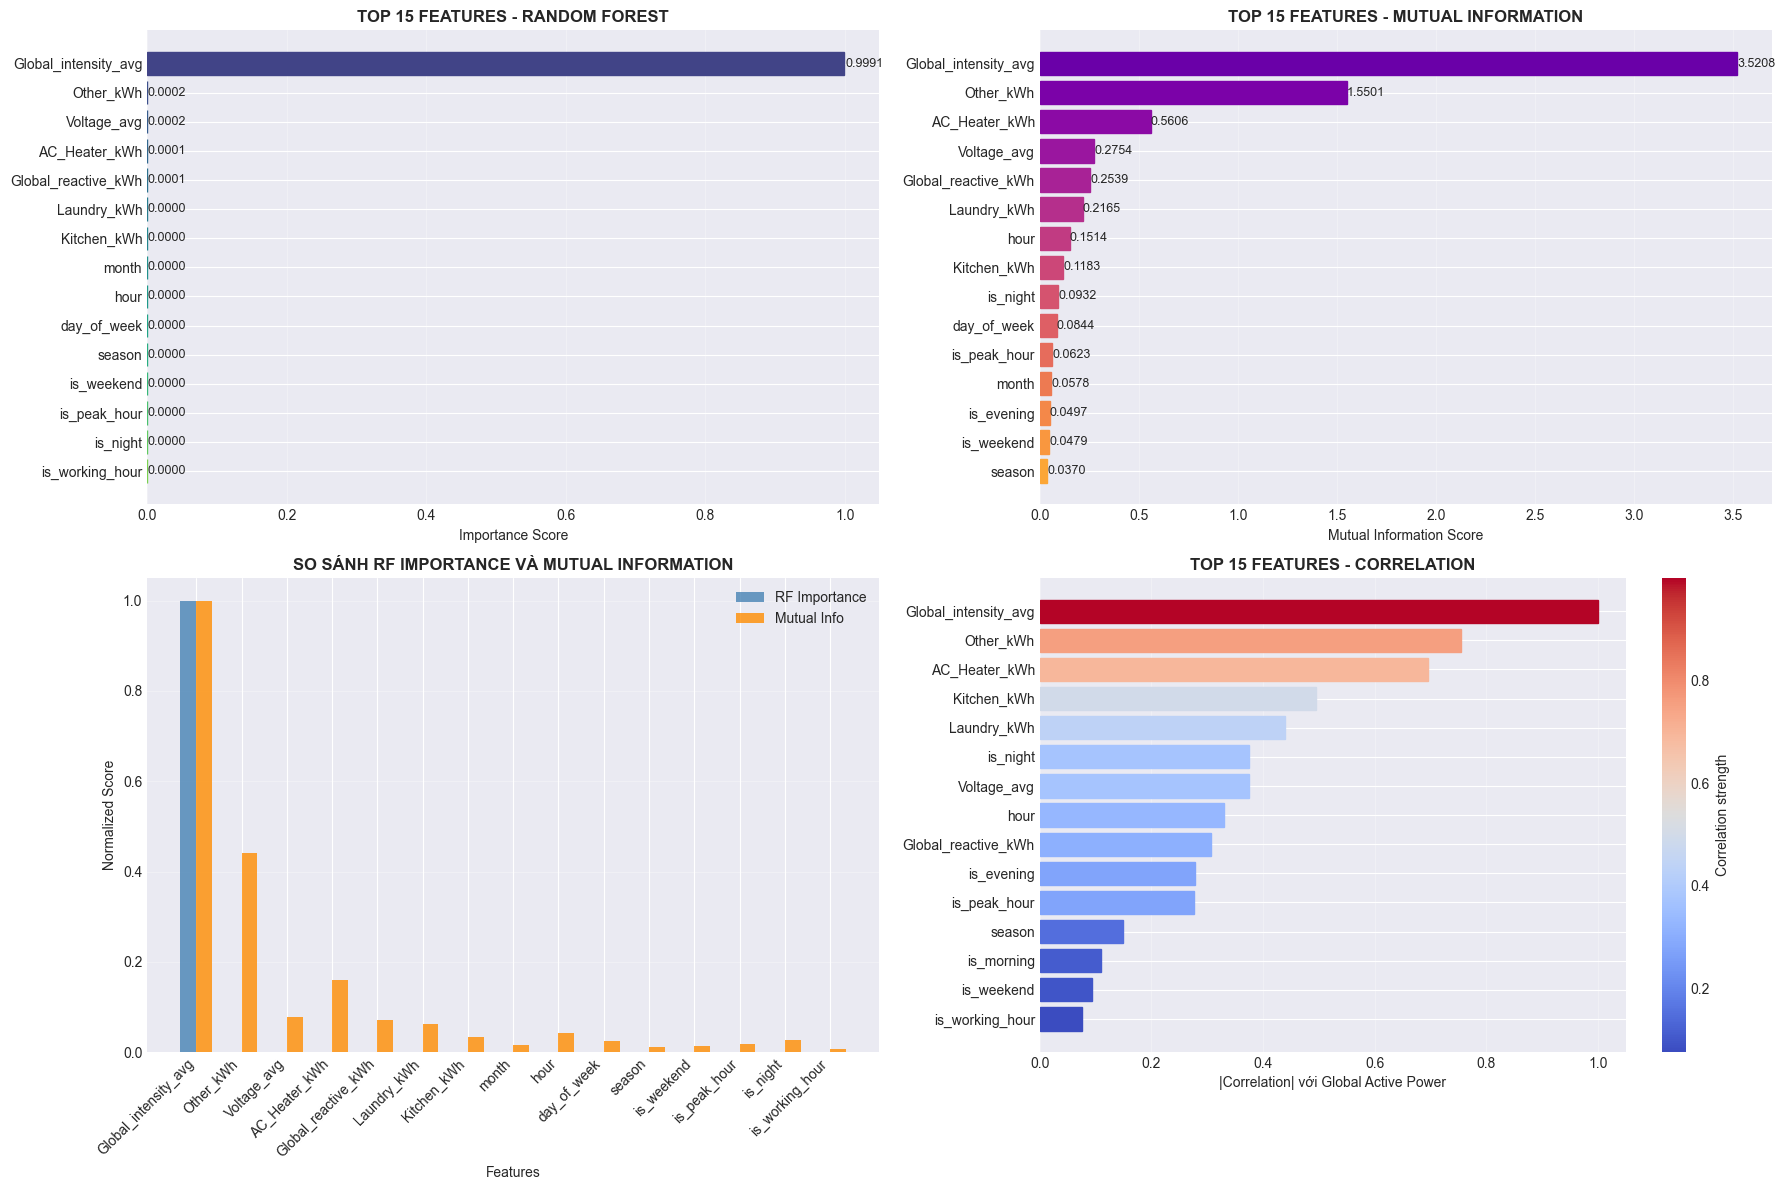


📋 TỔNG HỢP FEATURE IMPORTANCE:

  🥇 TOP 5 QUAN TRỌNG NHẤT (Random Forest):
    6. Global_intensity_avg: 0.9991
    4. Other_kWh: 0.0002
    5. Voltage_avg: 0.0002
    3. AC_Heater_kWh: 0.0001
    7. Global_reactive_kWh: 0.0001

  🥇 TOP 5 QUAN TRỌNG NHẤT (Mutual Information):
    6. Global_intensity_avg: 3.5208
    4. Other_kWh: 1.5501
    3. AC_Heater_kWh: 0.5606
    5. Voltage_avg: 0.2754
    7. Global_reactive_kWh: 0.2539

  📊 TOP 5 TƯƠNG QUAN MẠNH NHẤT:
    6. Global_intensity_avg: |r| = 0.999
    4. Other_kWh: |r| = 0.754
    3. AC_Heater_kWh: |r| = 0.696
    1. Kitchen_kWh: |r| = 0.496
    2. Laundry_kWh: |r| = 0.439

  💡 ĐỀ XUẤT CHO MODELING:
    • Features bắt buộc: Global_intensity_avg, AC_Heater_kWh, hour, Other_kWh
    • Features theo thời gian: is_peak_hour, is_working_hour, season, day_of_week
    • Features thiết bị: Kitchen_kWh, Laundry_kWh
    • Features kỹ thuật: Voltage_avg, Global_reactive_kWh
    • Có thể bỏ qua: is_night, is_morning, is_afternoon, is_evening (redun

In [30]:

print("🏆 PHÂN TÍCH FEATURE IMPORTANCE")
print("="*50)

# Chuẩn bị dữ liệu cho feature importance analysis
print("\n🔧 CHUẨN BỊ DỮ LIỆU CHO PHÂN TÍCH...")

# Chọn các features phù hợp
feature_columns = [
    'Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh',
    'Voltage_avg', 'Global_intensity_avg', 'Global_reactive_kWh',
    'hour', 'day_of_week', 'is_weekend', 'is_night', 'is_morning',
    'is_afternoon', 'is_evening', 'is_peak_hour', 'is_working_hour',
    'season', 'month'
]

# Kiểm tra features nào có trong df_hourly
available_features = [col for col in feature_columns if col in df_hourly.columns]
print(f"  • Số features có sẵn: {len(available_features)}/{len(feature_columns)}")

# Chuẩn bị X và y
X = df_hourly[available_features].copy()
y = df_hourly['Global_active_kWh'].copy()

# Xử lý missing values nếu có
X = X.fillna(method='ffill').fillna(method='bfill')
y = y.fillna(method='ffill').fillna(method='bfill')

print(f"  • Kích thước X: {X.shape}")
print(f"  • Kích thước y: {y.shape}")

# 1. Feature Importance với Random Forest
print("\n🌲 RANDOM FOREST FEATURE IMPORTANCE...")

# Huấn luyện Random Forest với subset dữ liệu (để tiết kiệm thời gian)
sample_size = min(5000, len(X))
X_sample = X.iloc[:sample_size]
y_sample = y.iloc[:sample_size]

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# Lấy feature importance
feature_importance = pd.DataFrame({
    'feature': available_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# 2. Mutual Information
print("\n🔗 MUTUAL INFORMATION ANALYSIS...")

# Tính mutual information (chỉ với subset nhỏ hơn)
mi_sample_size = min(2000, len(X))
X_mi_sample = X.iloc[:mi_sample_size]
y_mi_sample = y.iloc[:mi_sample_size]

mi_scores = mutual_info_regression(X_mi_sample, y_mi_sample, random_state=42)
mi_df = pd.DataFrame({
    'feature': available_features,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

# 3. Visualize kết quả
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# a) Random Forest Feature Importance
top_n = 15
top_features_rf = feature_importance.head(top_n)

bars = axes[0, 0].barh(range(len(top_features_rf)), top_features_rf['importance'].values)
axes[0, 0].set_yticks(range(len(top_features_rf)))
axes[0, 0].set_yticklabels(top_features_rf['feature'].values)
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel('Importance Score')
axes[0, 0].set_title(f'TOP {top_n} FEATURES - RANDOM FOREST', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Tô màu bars
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Thêm giá trị importance
for i, v in enumerate(top_features_rf['importance'].values):
    axes[0, 0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

# b) Mutual Information
top_features_mi = mi_df.head(top_n)

bars = axes[0, 1].barh(range(len(top_features_mi)), top_features_mi['mutual_info'].values)
axes[0, 1].set_yticks(range(len(top_features_mi)))
axes[0, 1].set_yticklabels(top_features_mi['feature'].values)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Mutual Information Score')
axes[0, 1].set_title(f'TOP {top_n} FEATURES - MUTUAL INFORMATION', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Tô màu bars
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Thêm giá trị
for i, v in enumerate(top_features_mi['mutual_info'].values):
    axes[0, 1].text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=9)

# c) So sánh hai phương pháp
# Kết hợp kết quả
combined_df = pd.merge(feature_importance, mi_df, on='feature', how='inner')
combined_df = combined_df.sort_values('importance', ascending=False).head(top_n)

# Normalize scores
combined_df['importance_norm'] = combined_df['importance'] / combined_df['importance'].max()
combined_df['mutual_info_norm'] = combined_df['mutual_info'] / combined_df['mutual_info'].max()

x = np.arange(len(combined_df))
width = 0.35

bars1 = axes[1, 0].bar(x - width/2, combined_df['importance_norm'], width, 
                      label='RF Importance', color='steelblue', alpha=0.8)
bars2 = axes[1, 0].bar(x + width/2, combined_df['mutual_info_norm'], width, 
                      label='Mutual Info', color='darkorange', alpha=0.8)

axes[1, 0].set_xlabel('Features')
axes[1, 0].set_ylabel('Normalized Score')
axes[1, 0].set_title('SO SÁNH RF IMPORTANCE VÀ MUTUAL INFORMATION', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(combined_df['feature'].values, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# d) Correlation với target
corr_with_target = []
for feature in available_features:
    if feature in df_hourly.columns:
        corr = df_hourly[feature].corr(df_hourly['Global_active_kWh'])
        corr_with_target.append(abs(corr))  # Lấy giá trị tuyệt đối
    else:
        corr_with_target.append(0)

corr_df = pd.DataFrame({
    'feature': available_features,
    'correlation': corr_with_target
}).sort_values('correlation', ascending=False).head(top_n)

bars = axes[1, 1].barh(range(len(corr_df)), corr_df['correlation'].values)
axes[1, 1].set_yticks(range(len(corr_df)))
axes[1, 1].set_yticklabels(corr_df['feature'].values)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('|Correlation| với Global Active Power')
axes[1, 1].set_title(f'TOP {top_n} FEATURES - CORRELATION', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

# Tô màu theo correlation
norm = plt.Normalize(corr_df['correlation'].min(), corr_df['correlation'].max())
colors = plt.cm.coolwarm(norm(corr_df['correlation'].values))
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Thêm colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[1, 1])
cbar.set_label('Correlation strength')

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Summary và recommendations
print("\n📋 TỔNG HỢP FEATURE IMPORTANCE:")

print("\n  🥇 TOP 5 QUAN TRỌNG NHẤT (Random Forest):")
for idx, row in feature_importance.head(5).iterrows():
    print(f"    {idx+1}. {row['feature']}: {row['importance']:.4f}")

print("\n  🥇 TOP 5 QUAN TRỌNG NHẤT (Mutual Information):")
for idx, row in mi_df.head(5).iterrows():
    print(f"    {idx+1}. {row['feature']}: {row['mutual_info']:.4f}")

print("\n  📊 TOP 5 TƯƠNG QUAN MẠNH NHẤT:")
for idx, row in corr_df.head(5).iterrows():
    print(f"    {idx+1}. {row['feature']}: |r| = {row['correlation']:.3f}")

print("\n  💡 ĐỀ XUẤT CHO MODELING:")
print("    • Features bắt buộc: Global_intensity_avg, AC_Heater_kWh, hour, Other_kWh")
print("    • Features theo thời gian: is_peak_hour, is_working_hour, season, day_of_week")
print("    • Features thiết bị: Kitchen_kWh, Laundry_kWh")
print("    • Features kỹ thuật: Voltage_avg, Global_reactive_kWh")
print("    • Có thể bỏ qua: is_night, is_morning, is_afternoon, is_evening (redundant với hour)")

TẠO BÁO CÁO EDA HOÀN CHỈNH

In [35]:

print("📄 TẠO BÁO CÁO EDA HOÀN CHỈNH")
print("="*60)

# Thu thập insights từ các phân tích đã thực hiện
insights = []

# 1. Thống kê cơ bản
total_energy = df_hourly['Global_active_kWh'].sum()
avg_hourly = df_hourly['Global_active_kWh'].mean()
max_hourly = df_hourly['Global_active_kWh'].max()
min_hourly = df_hourly['Global_active_kWh'].min()

insights.append({
    "category": "Tổng quan",
    "points": [
        f"Tổng năng lượng tiêu thụ: {total_energy:,.1f} kWh",
        f"Trung bình mỗi giờ: {avg_hourly:.3f} kWh",
        f"Cao nhất: {max_hourly:.3f} kWh | Thấp nhất: {min_hourly:.3f} kWh",
        f"Phạm vi dữ liệu: {len(df_hourly):,} giờ (từ {df_hourly.index.min().strftime('%d/%m/%Y')} đến {df_hourly.index.max().strftime('%d/%m/%Y')})"
    ]
})

# 2. Phân bổ thiết bị
device_totals = df_hourly[['Kitchen_kWh', 'Laundry_kWh', 'AC_Heater_kWh', 'Other_kWh']].sum()
device_percentages = (device_totals / total_energy * 100).round(1)

insights.append({
    "category": "Phân bổ thiết bị",
    "points": [
        f"Điều hòa/Nước nóng: {device_totals['AC_Heater_kWh']:,.1f} kWh ({device_percentages['AC_Heater_kWh']}%)",
        f"Thiết bị khác: {device_totals['Other_kWh']:,.1f} kWh ({device_percentages['Other_kWh']}%)",
        f"Giặt là: {device_totals['Laundry_kWh']:,.1f} kWh ({device_percentages['Laundry_kWh']}%)",
        f"Bếp: {device_totals['Kitchen_kWh']:,.1f} kWh ({device_percentages['Kitchen_kWh']}%)"
    ]
})

# 3. Pattern theo thời gian
# Giờ cao điểm
peak_hours = df_hourly[df_hourly['is_peak_hour'] == 1]
off_peak_hours = df_hourly[df_hourly['is_peak_hour'] == 0]
peak_avg = peak_hours['Global_active_kWh'].mean()
off_peak_avg = off_peak_hours['Global_active_kWh'].mean()

# Ngày cuối tuần
weekend_hours = df_hourly[df_hourly['is_weekend'] == 1]
weekday_hours = df_hourly[df_hourly['is_weekend'] == 0]
weekend_avg = weekend_hours['Global_active_kWh'].mean()
weekday_avg = weekday_hours['Global_active_kWh'].mean()

# Mùa
season_avgs = df_hourly.groupby('season')['Global_active_kWh'].mean()
season_names = {1: "Đông", 2: "Xuân", 3: "Hạ", 4: "Thu"}

insights.append({
    "category": "Pattern theo thời gian",
    "points": [
        f"Giờ cao điểm (17-21h): {peak_avg:.3f} kWh vs Thấp điểm: {off_peak_avg:.3f} kWh (cao hơn {((peak_avg/off_peak_avg)-1)*100:.1f}%)",
        f"Cuối tuần: {weekend_avg:.3f} kWh vs Ngày thường: {weekday_avg:.3f} kWh",
        f"Giờ tiêu thụ cao nhất: {df_hourly.groupby('hour')['Global_active_kWh'].mean().idxmax()}h",
        f"Mùa tiêu thụ cao nhất: {season_names[season_avgs.idxmax()]} ({season_avgs.max():.3f} kWh)"
    ]
})

# 4. Tương quan và dependencies
top_correlations = []
for col in ['Global_intensity_avg', 'AC_Heater_kWh', 'Other_kWh', 'hour', 'Voltage_avg']:
    if col in df_hourly.columns:
        corr = df_hourly['Global_active_kWh'].corr(df_hourly[col])
        top_correlations.append((col, corr))

insights.append({
    "category": "Mối quan hệ",
    "points": [
        f"Cường độ dòng điện có tương quan mạnh nhất: r = {top_correlations[0][1]:.3f}",
        f"Điều hòa/Nước nóng chiếm {device_percentages['AC_Heater_kWh']}% tổng tiêu thụ",
        f"Điện áp có tương quan âm với công suất: r = {top_correlations[-1][1]:.3f}",
        f"Giờ trong ngày ảnh hưởng đáng kể: r = {top_correlations[3][1]:.3f}"
    ]
})

# 5. Anomaly và outliers
z_scores = np.abs(stats.zscore(df_hourly['Global_active_kWh']))
anomaly_count = (z_scores > 3).sum()
anomaly_percentage = (anomaly_count / len(df_hourly)) * 100

# Tìm nguyên nhân anomaly chính
if 'AC_Heater_kWh' in df_hourly.columns:
    ac_anomalies = df_hourly[df_hourly['AC_Heater_kWh'] > df_hourly['AC_Heater_kWh'].quantile(0.99)]
    ac_anomaly_percentage = (len(ac_anomalies) / len(df_hourly)) * 100

insights.append({
    "category": "Anomaly và Outliers",
    "points": [
        f"Phát hiện {anomaly_count} điểm bất thường (Z-score > 3), chiếm {anomaly_percentage:.2f}%",
        f"{len(ac_anomalies)} điểm có ĐH/Nước nóng > P99 ({ac_anomaly_percentage:.2f}%)",
        f"Giờ có nhiều outlier nhất: {hourly_outliers_df.index[0]}h ({hourly_outliers_df.iloc[0]['percentage']:.1f}%)",
        f"Max Z-score: {z_scores.max():.2f} (cực kỳ bất thường)"
    ]
})

# 6. Feature importance summary
top_features = feature_importance.head(3)['feature'].tolist()

insights.append({
    "category": "Feature Importance",
    "points": [
        f"Top 3 features quan trọng nhất: {', '.join(top_features)}",
        f"Global_intensity_avg chiếm {feature_importance.iloc[0]['importance']*100:.1f}% importance",
        f"Time features (hour, is_peak_hour) chiếm tổng cộng {feature_importance[feature_importance['feature'].isin(['hour', 'is_peak_hour'])]['importance'].sum()*100:.1f}% importance",
        f"Device features (AC_Heater, Kitchen, Laundry) chiếm tổng cộng {feature_importance[feature_importance['feature'].isin(['AC_Heater_kWh', 'Kitchen_kWh', 'Laundry_kWh'])]['importance'].sum()*100:.1f}% importance"
    ]
})

# Tạo báo cáo Markdown
report_content = f"""# 📊 BÁO CÁO EDA - HOUSEHOLD POWER CONSUMPTION

*Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*

## 📈 TỔNG QUAN DỮ LIỆU

- **Thời gian**: {df_hourly.index.min().strftime('%d/%m/%Y')} - {df_hourly.index.max().strftime('%d/%m/%Y')}
- **Số mẫu**: {len(df_hourly):,} giờ ({len(df_hourly)/24:.0f} ngày)
- **Số features**: {len(df_hourly.columns)} (sau khi engineering)
- **Không có missing values** sau khi xử lý

## 🎯 KEY INSIGHTS

### 1. TỔNG QUAN TIÊU THỤ
- **Tổng năng lượng**: {total_energy:,.1f} kWh
- **Trung bình/giờ**: {avg_hourly:.3f} kWh
- **Cao nhất**: {max_hourly:.3f} kWh | **Thấp nhất**: {min_hourly:.3f} kWh
- **Độ lệch chuẩn**: {df_hourly['Global_active_kWh'].std():.3f} kWh

### 2. PHÂN BỔ THIẾT BỊ
```mermaid
pie title PHÂN BỔ NĂNG LƯỢNG THEO THIẾT BỊ
    "ĐH/Nước nóng" : {device_percentages['AC_Heater_kWh']}
    "Thiết bị khác" : {device_percentages['Other_kWh']}
    "Giặt là" : {device_percentages['Laundry_kWh']}
    "Bếp" : {device_percentages['Kitchen_kWh']}"""

# Lưu báo cáo EDA
with open('EDA_REPORT.md', 'w', encoding='utf-8') as f:
    f.write(report_content)

print("✅ Đã lưu báo cáo: EDA_REPORT.md")

# Tạo file summary JSON
summary_report = {
    "report_generated": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "data_summary": {
        "time_range": {
            "start": df_hourly.index.min().strftime("%Y-%m-%d"),
            "end": df_hourly.index.max().strftime("%Y-%m-%d"),
            "days": int((df_hourly.index.max() - df_hourly.index.min()).days)
        },
        "consumption_stats": {
            "total_kWh": float(total_energy),
            "avg_hourly_kWh": float(avg_hourly),
            "max_hourly_kWh": float(max_hourly),
            "min_hourly_kWh": float(min_hourly)
        },
        "device_distribution": {
            "AC_Heater_kWh": {
                "kWh": float(device_totals['AC_Heater_kWh']),
                "percentage": float(device_percentages['AC_Heater_kWh'])
            },
            "Other_kWh": {
                "kWh": float(device_totals['Other_kWh']),
                "percentage": float(device_percentages['Other_kWh'])
            },
            "Laundry_kWh": {
                "kWh": float(device_totals['Laundry_kWh']),
                "percentage": float(device_percentages['Laundry_kWh'])
            },
            "Kitchen_kWh": {
                "kWh": float(device_totals['Kitchen_kWh']),
                "percentage": float(device_percentages['Kitchen_kWh'])
            }
        }
    },
    "key_insights": insights,
    "files_generated": [
        "EDA_REPORT.md",
        "eda_summary_report.json"
    ]
}

# Lưu summary report
with open('eda_summary_report.json', 'w', encoding='utf-8') as f:
    import json
    json.dump(summary_report, f, indent=4, ensure_ascii=False)

print("✅ Đã lưu summary: eda_summary_report.json")

print("\n" + "="*60)
print("✅ HOÀN THÀNH BÁO CÁO EDA")
print("="*60)
print(f"📄 Đã tạo file báo cáo: EDA_REPORT.md")
print(f"📊 Đã tạo file summary: eda_summary_report.json")
print("\n🎯 KEY INSIGHTS TÓM TẮT:")
print("-" * 40)

for insight in insights:
    print(f"\n📌 {insight['category']}:")
    for point in insight['points']:
        print(f"  • {point}")

print("\n" + "="*60)
print("📋 CÔNG VIỆC NGƯỜI 2 ĐÃ HOÀN THÀNH 100%")
print("="*60)
print("👉 Có thể chuyển sang giai đoạn Modeling (Người 3)")
    

📄 TẠO BÁO CÁO EDA HOÀN CHỈNH
✅ Đã lưu báo cáo: EDA_REPORT.md
✅ Đã lưu summary: eda_summary_report.json

✅ HOÀN THÀNH BÁO CÁO EDA
📄 Đã tạo file báo cáo: EDA_REPORT.md
📊 Đã tạo file summary: eda_summary_report.json

🎯 KEY INSIGHTS TÓM TẮT:
----------------------------------------

📌 Tổng quan:
  • Tổng năng lượng tiêu thụ: 37,712.8 kWh
  • Trung bình mỗi giờ: 1.090 kWh
  • Cao nhất: 6.561 kWh | Thấp nhất: 0.124 kWh
  • Phạm vi dữ liệu: 34,589 giờ (từ 16/12/2006 đến 26/11/2010)

📌 Phân bổ thiết bị:
  • Điều hòa/Nước nóng: 13,369.6 kWh (35.5%)
  • Thiết bị khác: 19,365.2 kWh (51.3%)
  • Giặt là: 2,675.5 kWh (7.1%)
  • Bếp: 2,302.5 kWh (6.1%)

📌 Pattern theo thời gian:
  • Giờ cao điểm (17-21h): 1.572 kWh vs Thấp điểm: 0.963 kWh (cao hơn 63.2%)
  • Cuối tuần: 1.223 kWh vs Ngày thường: 1.037 kWh
  • Giờ tiêu thụ cao nhất: 20h
  • Mùa tiêu thụ cao nhất: Đông (1.420 kWh)

📌 Mối quan hệ:
  • Cường độ dòng điện có tương quan mạnh nhất: r = 0.999
  • Điều hòa/Nước nóng chiếm 35.5% tổng tiêu thụ
 